# 256-128x1 ...

---

In [ ]:
input_dir_name = "/kaggle/input/competitions/cayley-py-megaminx/"

cfg = {
        # Manage:
        'mode_train' : True,
        'only_train' : False,
        # 'load_ckpt' and 'path_ckpt' --> 'ckpt_from' in Curve class

        'k' : 1,

        # Neural network:
        'model_type': "ResMLP", # !!! ************************
        'hd1': 256,
        'hd2': 128,
        'nrd': 1,                  ## !!! ************************
        'n_attn_blocks': 0,
        'block_type': 'residual',        #residual, attn_res
        'dropout_rate': 0.0,

        'compile4train': False, # torch.compile() supported from torch 2.0
        'compilte4beam': False,
        'mode_compile': 'default', # 'max-autotune'
        'model.half': False, # model.half() - to fp16 - speeds up - used for inference, but can cause loss of precision
            # For models trained on very big number of epochs we observed that it causes significant losses of quality. But it general it just speeds up.

        # Training:
        "rw_width": 2500,
        "rw_length": 70,
        "rw_mode": "nbt",
        # "lr": ...,                ## !!! go to Curve class
        # "num_epochs": ...,            ## !!! go to Curve class
        "val_ratio": 1, # 0...1, zero - disables
        "batch_size": 1_000,

        # Beam search:
        'beam_width': 2**10,      # 2_000_000,
        'max_steps': 1000,        # limit of steps to stop beam search
        'beam_mode': "iterated",  #  "advanced", "simple",
        'history_depth': 10,      # how many steps to remember in history not to return there - non-backtracking for beam-serch
        'hashed_neigbourhood': 0, # To check arrival to some neigbourhood of the destination state
        'memory_cleanup': False,  # Periodically clean memory, may support a bit bigger beams, but causes slow down
        'return_path': True,      # return path or simply number of steps of the solution
        'path_device': 'cuda',    #  'auto',# 'cpu',  # Probably reduce memory to store path on cpu
        #Where to put a path values - controlled by param path_device
        #return_path = True and path_device = 'auto' -> path values are stored on CPU
        #return_path = False and path_device = 'auto' -> path values are stored on CUDA if it's available else CPU
        'verbose': 0,
        'frequency_to_print_log_in_beam_search':'auto',# 10, #

        # What states to be solved by beam search, and saved to submit file:
        # (for other states solutions will be borrowed from sample submit file)
        # Why: solving all states at once might be too long, option - select part - list of indexes
        # if emtpy list - then will solve all
        'list_states_to_solve':  list(range(901,1001)),
        }

paper_keys = (
    "arch",
    "solved", # percentage of sloved cases
    "length", # mean solution length
    "std", # solutions standard deviation
    "loss", # final loss
    "train_walks", # size of random walks dataset
    "size", # number of model's parameters
    "epochs", # number of epochs
    "lr", # learning rate
    "batch", # batch size
    "train_time", # training model time
    "beam_time" # beam search time
)

model_arch = f"{cfg['model_type']}_{cfg['hd1']}-{cfg['hd2']}x{cfg['nrd']}"

cfg["arch"] = model_arch

paper_dict = {
    "arch": model_arch,
    # "arch": f"ResMLP {cfg['hd1']}-{cfg['hd2']}x{cfg['nrd']}",   #
    # "epochs": str(cfg['num_epochs']),                           ## ************************
    # "lr": str(cfg['lr']),                                       ## ************************
    "batch": str(cfg['batch_size']),
    "std": str(0)
}

# install, init

## install

In [ ]:
!pip install git+https://github.com/cayleypy/cayleypy.git@e1518b6 --no-deps

  Cloning https://github.com/cayleypy/cayleypy.git (to revision e1518b6) to /tmp/pip-req-build-pkbg3fru
  Running command git clone --filter=blob:none --quiet https://github.com/cayleypy/cayleypy.git /tmp/pip-req-build-pkbg3fru
  Running command git checkout -q e1518b6
  Resolved https://github.com/cayleypy/cayleypy.git to commit e1518b6
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for cayleypy: filename=cayleypy-0.1.0-py3-none-any.whl size=592104 sha256=f39ad39ac8cd27d60b25da2e4bc11a639f86c7858e3f19f75dedca365a65c437
  Stored in directory: /tmp/pip-ephem-wheel-cache-n2kkej1j/wheels/08/bc/a8/7ee0e8ea5fadb768168c45a97c69450c8a37a112c4417d83ae
Successfully built cayleypy


In [ ]:
from datetime import datetime
from datetime import timedelta
from dataclasses import dataclass, field
import pickle
import shutil
import time
import copy
from copy import deepcopy
from collections import defaultdict
from statistics import mean

from IPython.display import display
from PIL import Image

import json
import logging
from pathlib import Path
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split
import torch
from torch import nn

from cayleypy import CayleyGraphDef, CayleyGraph, Predictor

import matplotlib.pyplot as plt
import seaborn as sns

logger = logging.getLogger()
logging.basicConfig(level=20)


print(torch.__version__)

2.11.0+cu128


In [ ]:
try:
    print('Cuda device name:',  torch.cuda.get_device_name(0) )
except:
    print('Except for torch.cuda.get_device_name(0) ')

Cuda device name: Tesla T4


## Load data to solve and sample submit

In [ ]:
### Some utilities ###

def parse_initial_state(inital_state_str: str) -> np.ndarray:
    return np.array([int(x) for x in inital_state_str.split(",")])

def parse_path(path_str: str) -> list[str]:
    return list(path_str.split("."))

def check_path(path_to_check: dict[str, np.ndarray], inital_state: np.ndarray, central_state: np.ndarray, generators: dict[str, np.ndarray]) -> bool:
    state = initial_state
    for gen_name in path_to_check:
        gen = generators[gen_name]
        state = state[gen]
    return np.all(state==central_state)

### Loading competition inputs ###


# INPUTS_DIR = Path(input_dir_name)
INPUTS_DIR = '/content/'

# with open(INPUTS_DIR/"puzzle_info.json", "r") as file:
with open(f"{INPUTS_DIR}puzzle_info.json", "r") as file:
    puzzle_info = json.load(file)


central_state = np.array(puzzle_info["central_state"])
generators = {k: np.array(v) for k, v in puzzle_info["generators"].items()}


# df_test = pd.read_csv(INPUTS_DIR/"test.csv", index_col = "initial_state_id")
# df_sample_submission = pd.read_csv(INPUTS_DIR/"sample_submission.csv", index_col = "initial_state_id")
df_test = pd.read_csv(f"{INPUTS_DIR}test.csv", index_col = "initial_state_id")
df_sample_submission = pd.read_csv(f"{INPUTS_DIR}sample_submission.csv", index_col = "initial_state_id")

display(df_test.head(2) )
print(' len( central_state ):', len( central_state )    )
df_sample_submission.head(20)

,initial_state
initial_state_id,
0,"0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18..."
1,"0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,22..."


 len( central_state ): 120


,path
initial_state_id,
0,BR.U.BL.B.DR.B.D.-BL.FR.D.DL.FL.DL.BL.U.L.-F.-...
1,BR
2,BL.-L
3,R.-DR.BR
4,FR.-BL.BR.DL
5,DL.-B.-BR.U.FR
6,BL.U.-FL.-B.-FL.-FR
7,-F.-BL.-BL.-L.-R.B.-FR
8,F.DR.-FR.-L.-L.-BR.BR.-DR


## Create Cayley graph

In [ ]:
### Preparing CayleyPy graph ###

gens_names = list(generators.keys())
graph_def = CayleyGraphDef.create(
    generators = [generators[x] for x in gens_names],
    generator_names = gens_names,
    central_state = central_state
)

# Important: small batch_size may lead to significant slowing down the beam search, e.g. values like 2**8, but potentially better RAM utilization.
graph = CayleyGraph(graph_def,  dtype = torch.int8, bit_encoding_width=None,
                    batch_size = 2**16,  hash_chunk_size = 2**16  )

/usr/local/lib/python3.13/dist-packages/cayleypy/cayley_graph.py:102: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  self.permutations_torch = torch.tensor(


In [ ]:
# graph created --> can add to cfg
cfg['num_classes'] = int(max(graph.central_state))+1
cfg['state_size'] =  graph.definition.state_size

## Define models architechtures (new)

In [ ]:
from dataclasses import dataclass
from typing import Any, Optional

import torch.nn as nn
import torch.nn.functional as F
import math

class RMSNorm(nn.Module):
    def __init__(self, hidden_dim, eps=1e-6):
        super().__init__()
        self.weight = nn.Parameter(torch.ones(hidden_dim))
        self.eps = eps

    def forward(self, x):
        # x: [*, hidden_dim]
        rms = torch.sqrt(x.pow(2).mean(-1, keepdim=True) + self.eps)
        return x / rms * self.weight

class AttnResidualBlock(nn.Module):
    def __init__(self, hidden_dim, dropout_rate=0.1):
        super().__init__()

        self.fc1 = nn.Linear(hidden_dim, hidden_dim)
        self.bn1 = nn.BatchNorm1d(hidden_dim)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout_rate)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.bn2 = nn.BatchNorm1d(hidden_dim)

        self.query = nn.Parameter(torch.randn(hidden_dim) * 0.02)   # w_l
        self.rmsnorm = RMSNorm(hidden_dim)

        nn.init.zeros_(self.query)

    def forward(self, x, prev_outputs):
        """
        x: the current input of the block (after the previous aggregation)
        prev_outputs: a list of tensors [num_prev, batch, hidden_dim] – outputs of all previous blocks
        Returns: output tensor [batch, hidden_dim]
        """
        residual = x
        out = self.fc1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.dropout(out)
        out = self.fc2(out)
        out = self.bn2(out)

        if len(prev_outputs) > 0:
            values = torch.stack(prev_outputs, dim=0)  # [P, B, D]

            keys = self.rmsnorm(values)                # [P, B, D]

            q = self.query.view(1, 1, -1).expand(1, values.size(1), -1)

            logits = torch.einsum('b d, p b d -> p b', q.squeeze(0), keys)  # [P, B]
            weights = F.softmax(logits, dim=0)          # [P, B]
            weights = weights.unsqueeze(-1)             # [P, B, 1]

            agg = (weights * values).sum(dim=0)         # [B, D]
        else:
            agg = torch.zeros_like(out)

        out = out + agg

        out = self.relu(out)
        return out


class PilgrimAttnRes(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.dtype = torch.float32
        self.state_size = config['state_size']
        self.num_classes = config['num_classes']
        self.hd1 = config['hd1']
        self.hd2 = config['hd2']
        self.nrd = config['nrd']
        self.n_attn_blocks = config.get('n_attn_blocks', 0)
        self.block_type = config.get('block_type', 'residual')
        self.z_add = 0
        self.output_dim = 1

        state_size = self.state_size
        num_classes = self.num_classes
        hd1 = self.hd1
        hd2 = self.hd2
        dropout_rate = config['dropout_rate']

        self.input_layer = nn.Linear(state_size * num_classes, hd1)
        self.bn1 = nn.BatchNorm1d(hd1)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout_rate)

        if hd2 > 0:
            self.hidden_layer = nn.Linear(hd1, hd2)
            self.bn2 = nn.BatchNorm1d(hd2)
            hidden_dim_for_output = hd2
        else:
            self.hidden_layer = None
            self.bn2 = None
            hidden_dim_for_output = hd1

        if self.block_type == 'residual':
            self.residual_blocks = nn.ModuleList(
                [ResidualBlock(hd2, dropout_rate) for _ in range(self.nrd)]
            ) if self.nrd > 0 and hd2 > 0 else None
        elif self.block_type == 'attn_res':
            self.residual_blocks = nn.ModuleList(
                [AttnResidualBlock(hd2, dropout_rate) for _ in range(self.n_attn_blocks)]
            ) if self.n_attn_blocks > 0 and hd2 > 0 else None
        else:
            raise ValueError(f"Unknown block_type: {self.block_type}")

        self.output_layer = nn.Linear(hidden_dim_for_output, self.output_dim)

    def forward(self, z):
        x = F.one_hot(z.long() + self.z_add, num_classes=self.num_classes).view(z.size(0), -1).to(self.dtype)

        x = self.input_layer(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.dropout(x)

        if self.hidden_layer is not None:
            x = self.hidden_layer(x)
            x = self.bn2(x)
            x = self.relu(x)
            x = self.dropout(x)

        if self.residual_blocks is not None:
            if self.block_type == 'residual':
                for block in self.residual_blocks:
                    x = block(x)
            elif self.block_type == 'attn_res':
                prev_outputs = []
                for block in self.residual_blocks:
                    x = block(x, prev_outputs)
                    prev_outputs.append(x)

        x = self.output_layer(x)
        return x.flatten()


class ResidualBlock(nn.Module):
    def __init__(self, hidden_dim, dropout_rate=0.1):
        super(ResidualBlock, self).__init__()
        self.fc1 = nn.Linear(hidden_dim, hidden_dim)
        self.bn1 = nn.BatchNorm1d(hidden_dim)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout_rate)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.bn2 = nn.BatchNorm1d(hidden_dim)

    def forward(self, x):
        residual = x
        out = self.fc1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.dropout(out)
        out = self.fc2(out)
        out = self.bn2(out)
        out = out + residual
        out = self.relu(out)
        return out

## Fuctions for train-val

### metric funcs

In [ ]:
# to check gradients on different layers
def grad_norm(module):
    total = 0.0

    for p in module.parameters():
        if p.grad is not None:
            total += p.grad.norm().item() ** 2

    return total ** 0.5

In [ ]:
# how large weights on the layer
# helps catch a "weight inflation" regime

def weight_norm(module):
    s = 0.
    for p in module.parameters():
        s += p.data.norm().item()**2
    return s**0.5

In [ ]:
# parameter update magnitude
# for SGD ΔW=−lr⋅g
# for Adam ΔW=−lr*m/(sqrt(v)​+ϵ​)

def adam_update_norm(optimizer, module):
    total = 0.0

    params = set(module.parameters())

    for group in optimizer.param_groups:
        lr = group['lr']

        for p in group['params']:
            if p not in params:
                continue

            state = optimizer.state[p]

            if 'exp_avg' not in state:
                continue

            m = state['exp_avg']
            v = state['exp_avg_sq']

            update = lr * m / (v.sqrt() + 1e-8)

            total += update.norm().item()**2

    return total**0.5

In [ ]:
def flatten_parameters(module):
    return torch.cat([
        p.detach().view(-1)
        for p in module.parameters()
        if p.requires_grad
    ])

In [ ]:
# def metrics_init(model):
#     return {
#         "prev_params": flatten_parameters(model).clone(),
#         "prev_update": None,
#         "update_norm_history": [],
#         "prev_val_loss": None,
#     }

### get layers and stats funcs

In [ ]:
# +
def get_layers(model):
    layer_list = []
    for name, module in model.named_modules():
        if (not isinstance(module, nn.ReLU)) and (not isinstance(module, nn.Dropout)):
            layer_list.append((name, module))

    return dict(layer_list)

In [ ]:
# +
def get_layer_metrics(layer, optimizer, epoch):

    eps = 1e-12

    g = grad_norm(layer)
    w = weight_norm(layer)
    u = adam_update_norm(optimizer, layer)

    grad = g
    weight = w
    grad_weight = g / (w + eps)
    adam = u
    adam_weight = u / (w + eps)

    metrics = {

        "epoch": epoch,

        "grad_norm": grad,
        "weight_norm": weight,
        "grad_weight_ratio": grad_weight,

        "adam_update_norm": adam,
        "update_weight_ratio": adam_weight,
    }

    return metrics

In [ ]:
# +
def get_net_metrics(
    model,
    optimizer,
    tracker,
    epoch,
    train_loss=None,
    val_loss=None,
    history_window=20,
    ):

    eps = 1e-12

    current_params = flatten_parameters(model)
    previous_params = tracker["prev_params"]


    # epoch_displacement -- Absolute amount the parameters moved during an epoch
    # and
    # relative_parameter_displacement -- Parameter movement relative to parameter magnitude

    displacement = current_params - previous_params

    displacement_norm = displacement.norm()

    previous_weight_norm = previous_params.norm()

    # previous_weight_norm is used -->
    # how large was the step compared to the model that generated it
    relative_parameter_displacement = (
        displacement_norm /
        (previous_weight_norm + eps)
    )

    # cosine between successive parameter updates
    # == Directional similarity between consecutive epoch updates
    # == Directional persistence of parameter updates
    #
    # +1 : consecutive updates have very similar directions
    #  0 : consecutive updates are approximately orthogonal
    # -1 : consecutive updates point in opposite directions
    #
    # cosine by itself isn't an optimization-quality metric


    if tracker["prev_update"] is None:
        cosine = np.nan
    else:
        cosine = F.cosine_similarity(
            displacement,
            tracker["prev_update"],
            dim=0,
        ).item()


    # update variance
    # Large variance --> update magnitudes vary strongly
    # Small variance --> update magnitudes are more consistent


    tracker["update_norm_history"].append(displacement_norm.item())

    history = tracker["update_norm_history"][-history_window:]

    update_variance = (
        float(np.var(history))
        if len(history) > 1
        else np.nan
    )


    # validation improvement -- Change in validation loss
    # -- How did the loss on this newly sampled validation population
    #    differ from the loss on the previous newly sampled validation population?

    if tracker["prev_val_loss"] is None or val_loss is None:
        val_improvement = np.nan
    else:
        val_improvement = (
            tracker["prev_val_loss"] - val_loss
        )


    # improvement per movement (or parameter)
    # --- Validation improvement normalized by parameter movement
    # How much validation loss did one unit of parameter movement buy?

    # Near zero -- network moves , but validation does not.
    # Negative -- network moves and validation gets worse.


    if np.isnan(val_improvement):
        improvement_per_displacement = np.nan
    else:
        improvement_per_displacement = (
            val_improvement /
            (displacement_norm.item() + eps)
        )


    # update tracker
    #------------------

    tracker["prev_params"] = current_params.clone()

    tracker["prev_update"] = displacement.clone()

    if val_loss is not None:
        tracker["prev_val_loss"] = val_loss

    ####################################################################
    # output
    ####################################################################

    stats = {

        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_loss,

        "epoch_displacement": displacement_norm.item(),

        "relative_parameter_displacement": relative_parameter_displacement.item(),

        "cosine_update": cosine,

        "update_variance": update_variance,

        "validation_improvement": val_improvement,

        "improvement_per_displacement":
            improvement_per_displacement,
    }

    return stats, tracker


In [ ]:
def collect_stats(
    model,
    optimizer,
    epoch,
    ):

    stats = {}

    layers = get_layers(model)

    for name, layer in layers.items():
        stats[name] = get_layer_metrics(layer, optimizer, epoch)

    return stats

### class Curve + load results func

In [ ]:
# from dataclasses import dataclass, field

@dataclass
class Curve:

    cfg: dict

    group_names: set

    num_epochs: int

    #-------------------
    # current state

    is_broken: bool = False

    total_train_time: timedelta = timedelta(0)

    total_num_epochs: int = 0

    schedule: dict | None = None

    name: str | None = None

    current_epoch: int = 0

    ckpt_from: str | None = None

    checkpoints: list = field(default_factory=list)

    net_metrics: list = field(default_factory=list)

    layer_metrics: list = field(default_factory=list)

    tracker: dict = None

    save_best: bool = False

    threshold_epochs: list | None = None
    threshold_val_losses: list | None = None
    threshold_ma50s: list | None = None

    saved_th_val_losses: set = field(default_factory=set)
    saved_th_ma50s: set = field(default_factory=set)

    verbose: bool =True,       # print training information
    save_files: bool =True,    # save checkpoints/CSVs/etc.

    #--------------------------------------------------

    def __post_init__(self):

        if self.schedule is None:
            self.is_broken = True
            print("schedule is mandatory!!!")
            return

        if self.threshold_epochs is None:
            self.threshold_epochs = [self.num_epochs - 1]

        if self.threshold_val_losses is None:
            self.threshold_val_losses = []

        if self.threshold_ma50s is None:
            self.threshold_ma50s = []

        if self.saved_th_val_losses is None:
            self.saved_th_val_losses = set()

        if self.saved_th_ma50s is None:
            self.saved_th_ma50s = set()

        self.name = f"nrd{self.cfg['nrd']}_" + self.schedule_to_name(self.name, self.schedule, self.num_epochs)

        if self.group_names != {""}:
            self.schedule = self.expand_schedule(self.schedule)

    #--------------------------------------------------
    # save and archive .csv files

    def results_dir(self, root="experiments"):
        return Path(root) / self.name

    def save_metrics_to_csv(self, root="experiments"):

        output_dir = Path(root) / self.name
        output_dir.mkdir(parents=True, exist_ok=True)

        net_metrics = self.build_curves_per_net(self.net_metrics)
        net_df = self.get_net_metrics_df(net_metrics)

        net_df.to_csv(
            output_dir / "net_metrics.csv",
            index=False
        )

        layers = list(self.layer_metrics[0].keys())

        layer_metrics = self.build_curves_per_layer(
            self.layer_metrics
        )

        list_of_dfs = self.get_layers_metric_per_layer_df(
            layer_metrics,
            # layers
        )

        for layer, df in list_of_dfs:
            df.to_csv(
                output_dir / f"{layer}.csv",
                index=False
            )

        layers_df = pd.DataFrame({
            "layer": layers,
            "curve_name": self.name,
            "schedule": str(self.schedule),
            "nrd": self.cfg["nrd"],
        })

        layers_df.to_csv(
            output_dir / "layers.csv",
            index=False
        )

    def archive_metrics(self, root_dir="experiments"):

        curve_dir = Path(root_dir) / self.name

        archive_path = shutil.make_archive(
            str(curve_dir),
            "zip",
            root_dir=curve_dir,
        )

        print(f"Archive saved: {archive_path}")

        return archive_path

    #--------------------------------------------------
    def get_ma50(self):
        if not self.net_metrics:
            return np.nan

        val_losses = [
            metric["val_loss"]
            for metric in self.net_metrics
        ]

        return float(np.mean(val_losses[-50:]))
    #--------------------------------------------------
    @staticmethod
    def schedule_to_name(name, schedule, num_epochs):

        if name:
            return name

        if not schedule:
            return f"{num_epochs}ep" # "+" -- removed

        if "" not in schedule:
            return f"{num_epochs}ep-multi_lr"

        sched = schedule[""]

        epochs = list(sched.keys()) + [num_epochs]

        names = []

        for i, lr in enumerate(sched.values()):

            length = epochs[i+1] - epochs[i]

            lr_str = "{:.0e}".format(lr).replace("-0","")

            names.append(f"{length}ep{lr_str}")

        return "_".join(names)

    #--------------------------------------------

    def expand_schedule(self, current_schedule):
        """
        Replace "" by all optimizer groups.

        """

        schedule = copy.deepcopy(current_schedule)

        if "" not in schedule:
            return schedule

        default_schedule = schedule.pop("")

        expanded = {}

        for group_name in self.group_names:

            if group_name in schedule:
                expanded[group_name] = schedule[group_name]
            else:
                expanded[group_name] = copy.deepcopy(default_schedule)

        return expanded

    #--------------------------------------------
    def ckpt_name(self):

        return f"ckpt_{self.cfg['arch']}_{self.name}_ep"

    #--------------------------------------------
    def clone(self):

        new_curve = deepcopy(self)

        return new_curve


    #----------------------------------------

    def adapt_schedule(self, schedule):

        adapted_schedule ={}

        for name, lr_schedule in schedule.items():
            adapted_schedule[name]={}

            for epoch, lr in lr_schedule.items():
                switch_epoch = self.current_epoch + epoch + 1
                adapted_schedule[name][switch_epoch] = lr

        return adapted_schedule
    #----------------------------------------

    def deep_merge(self, dict1, dict2):
        # Start with a shallow copy of dict1
        result = dict1.copy()

        for key, value in dict2.items():
            # If both values are dictionaries, merge them recursively
            if key in result and isinstance(result[key], dict) and isinstance(value, dict):
                result[key] = self.deep_merge(result[key], value)
            else:
                # Otherwise, overwrite or add the value
                result[key] = value

        return result
    #----------------------------------------


    def extend(
        self,
        num_epochs,
        schedule=None,
        name=None,
        threshold_epochs=None,
        threshold_val_losses=[],
        threshold_ma50s=[],
        save_best=None,
    ):

        if save_best:
            self.save_best = save_best

        if threshold_epochs is None:
            threshold_epochs = [num_epochs - 1]

        part_name = self.schedule_to_name(name, schedule, num_epochs)

        self.num_epochs = num_epochs

        self.name += "_" + part_name

        if schedule:

            adapted_schedule = self.adapt_schedule(schedule)

            if self.group_names != {""}:
                expanded_scheduler = self.expand_schedule(adapted_schedule)
            else:
                expanded_scheduler = adapted_schedule

            self.schedule = self.deep_merge(self.schedule, expanded_scheduler)

        self.threshold_epochs.extend(
            [ (self.current_epoch + e + 1) for e in threshold_epochs ]
        )

        self.threshold_val_losses.extend(threshold_val_losses)
        self.threshold_ma50s.extend(threshold_ma50s)

    #--------------------------------------------------------------
    def update_after_training(
        self,
        last_epoch,
        last_ckpt,
        tracker=None,
        train_time=datetime.now(),
    ):

        self.current_epoch = last_epoch

        self.ckpt_from = last_ckpt

        self.total_num_epochs = self.current_epoch + 1

        # if tracker:
        #     self.tracker = tracker
        self.tracker = tracker

        self.total_train_time += train_time

    #------------------------
    # save and load curve object

    def get_basic_file_name_for_curve(self):
        return f"curve_{self.name}_ep{self.current_epoch}.pkl"

    def save(self, file_name=None):
        if file_name is None:
            file_name = self.get_basic_file_name_for_curve()

        with open(file_name, "wb") as f:
            pickle.dump(self, f)

        print(f"curve saved: {file_name}")

    @classmethod
    def load(cls, file_name):
        with open(file_name, "rb") as f:
            return pickle.load(f)

    #-----------------------
    # functions to build metrics for plotting

    @staticmethod
    def build_curves_per_net(curve_net_metrics):

        curves = {}

        for epoch_stats in curve_net_metrics:

            for k, v in epoch_stats.items():
                if not curves.get(k, []):
                    curves[k] = [v]
                else:
                    curves[k].append(v)

        return curves

    @staticmethod
    def build_curves_per_layer(curve_layer_metrics):

        curves = {}

        for epoch_stats in curve_layer_metrics:

            for layer_key, layer_stats in epoch_stats.items():

                if layer_key not in curves:
                    curves[layer_key] = {
                        k: [] for k in layer_stats.keys()
                    }

                for k, v in layer_stats.items():
                    curves[layer_key][k].append(v)

        return curves

    #-----------------------
    def get_net_metrics_df(self, metrics):

        df = pd.DataFrame(metrics)

        df["val_loss_MA20"] = (
            df["val_loss"]
            .rolling(window=20, min_periods=1)
            .mean()
        )

        df["val_loss_MA50"] = (
            df["val_loss"]
            .rolling(window=50, min_periods=1)
            .mean()
        )

        # ---- curve metadata ----
        df["curve_name"] = self.name
        df["schedule"] = str(self.schedule)
        df["nrd"] = self.cfg["nrd"]

        return df

    def get_layers_metric_per_layer_df(self, layer_metrics):

        result = []

        for layer_name, metrics in layer_metrics.items():

            df = pd.DataFrame(metrics)

            # ---- metadata ----
            df["curve_name"] = self.name
            df["schedule"] = str(self.schedule)
            df["nrd"] = self.cfg["nrd"]
            df["layer_name"] = layer_name

            result.append((layer_name, df))

        return result
    #-----------------------

In [ ]:
def load_curve_results(curve_name, root="experiments"):

    path = Path(root) / curve_name

    result = {
        "net": pd.read_csv(path / "net_metrics.csv"),
        "layers": pd.read_csv(path / "layers.csv"),
    }

    return result

### class CheckpointInfo

In [ ]:
@dataclass
class CheckpointInfo:

    epoch: int

    file: str

    val_loss: float

    ma50: float

    train_loss: float

    reason: set

    is_best: bool

    train_walks: str

    train_time_str: str

    train_time: timedelta = field(default_factory=timedelta)





### class Trainer

In [ ]:
class Trainer:

    def __init__(self, graph, model, optimizer, loss_fn):

        self.model = model

        self.optimizer = optimizer

        self.loss_fn = loss_fn

        self.device=graph.device

        self.graph = graph

    #-----------------------------------------------
    @staticmethod
    def get_train_time_str(train_time):

        hours = train_time.seconds // 3600
        minutes = (train_time.seconds % 3600) // 60
        sec = (train_time.seconds % 3600) % 60

        return f"{hours}h{minutes}m" if hours > 0 else f"{minutes}m{sec}s"
    #-----------------------------------------------
    @staticmethod
    def get_train_walks(curve):
        try :
            sz = curve.cfg["rw_width"] * curve.cfg["rw_length"] * curve.total_num_epochs
            millions = sz/1e6

            if millions < 1000:
                train_walks = str(int(millions)) + "M"
            else:
                train_walks = str(millions/1000) + "B"
        except Exception as e:
            print("Error occurred:", e)
            train_walks = f"Error: {e}"

        return train_walks

    #-----------------------------------------------

    def update_lr_schedule(
        self,
        lr_schedule,
        epoch):

        changed = []

        for group in self.optimizer.param_groups:

            name = group["name"]

            if name in lr_schedule:
                schedule = lr_schedule[name]
            else:
                schedule = lr_schedule[""]

            if epoch in schedule:

                new_lr = schedule[epoch]

                group["lr"] = new_lr

                changed.append((name, new_lr))

        return changed
    #-----------------------------------------------
    @staticmethod
    def get_save_reasons(epoch, val_loss, ma50, curve):

        reasons = set()

        # epoch_condition
        if (epoch in curve.threshold_epochs):
            reasons.add("th_epoch")

        # val_loss_condition
        for th in curve.threshold_val_losses:
            if (
                (val_loss <= th)
                and (th not in curve.saved_th_val_losses)
            ):
                reasons.add("th_loss")
                curve.saved_th_val_losses.add(th)

        # ma_condition
        for th in curve.threshold_ma50s:
            if (
                (ma50 <= th)
                and (th not in curve.saved_th_ma50s)
            ):
                reasons.add("th_ma50")
                curve.saved_th_ma50s.add(th)

        return reasons
    #-----------------------------------------------
    def metrics_init(self):
        return {
            "prev_params": flatten_parameters(self.model).clone(),
            "prev_update": None,
            "update_norm_history": [],
            "prev_val_loss": None,
        }

    #-----------------------------------------------


    def generate_epoch_data(self, curve):

        X, y = self.graph.random_walks(
            width=curve.cfg["rw_width"],
            length=curve.cfg["rw_length"],
            mode=curve.cfg["rw_mode"],
            nbt_history_depth=curve.cfg["rw_length"],
        )

        y = y.float()
        indices = torch.randperm(X.shape[0])
        X = X[indices]
        y = y[indices]

        return X, y


    def train_epoch(self,
                    curve, X_train, y_train,
                    ):

        train_size = len(X_train)
        self.model.train()
        batch_size = curve.cfg["batch_size"]
        total_train_loss=0


        for start in range(0, train_size, batch_size):
            end = min(start + batch_size, train_size)
            xb = X_train[start:end]
            yb = y_train[start:end].float().squeeze()
            pred = self.model(xb).squeeze()
            loss = self.loss_fn(pred, yb)
            self.optimizer.zero_grad()
            loss.backward()
            self.optimizer.step()
            total_train_loss += loss.item() * xb.size(0)


        avg_train_loss = float(total_train_loss / train_size)

        return avg_train_loss


    def validate_epoch(self, curve, X_val, y_val):

        if (curve.cfg["val_ratio"]> 0) :

            self.model.eval()
            total_val_loss = 0
            val_size = X_val.shape[0]

            with torch.no_grad():
                for start in range(0, val_size, curve.cfg["batch_size"]):
                    end = min(start + curve.cfg["batch_size"], val_size)
                    xb = X_val[start:end]
                    yb = y_val[start:end].float().squeeze()
                    pred = self.model(xb).squeeze()
                    loss = self.loss_fn(pred, yb)
                    total_val_loss += loss.item() * xb.size(0)
            avg_val_loss = total_val_loss / val_size

        else:
            avg_val_loss = np.nan

        return avg_val_loss


    def train(self, curve):

        start_time = datetime.now()

        if curve.verbose:
            print(f"\nTraining {curve.name}")

        self.model.to(self.device)

        for state in self.optimizer.state.values():
            for k, v in state.items():
                if isinstance(v, torch.Tensor) and v.device != self.device:
                    state[k] = v.to(self.device)

        if not curve.tracker:
            curve.tracker = self.metrics_init()

        # best validation loss
        best_val_loss = float('inf')
        best_ma50 = float('inf')
        best_train_loss = float('inf')
        best_epoch = -1
        saved_best = set()
        best_start = start_time
        best_end = start_time
        best_train_time = curve.total_train_time
        best_ckpt_file_name = f"{curve.ckpt_name()}.pth"

        for epoch in range(curve.current_epoch,
                           curve.current_epoch + curve.num_epochs):

            changed_lr = self.update_lr_schedule(
                    curve.schedule,
                    epoch
                )

            if changed_lr and curve.verbose:
                print(f"\nEpoch {epoch}. Switch LR.")

                for name, lr in changed_lr:
                    print(f"{name:25s} lr -> {lr}")

            #
            # current training loop
            #

            X_train, y_train = self.generate_epoch_data(curve)

            train_loss = self.train_epoch(curve, X_train, y_train)

            X_val, y_val = self.generate_epoch_data(curve)

            val_loss = self.validate_epoch(curve, X_val, y_val)

            layer_metrics = collect_stats(
                model=self.model,
                optimizer=self.optimizer,
                epoch=epoch,
            )

            net_metrics, tracker = get_net_metrics(
                model=self.model,
                optimizer=self.optimizer,
                tracker=curve.tracker,
                epoch=epoch,
                train_loss=train_loss,
                val_loss=val_loss,
            )

            curve.net_metrics.append(net_metrics)
            curve.layer_metrics.append(layer_metrics)

            ma50 = curve.get_ma50()

            #----------------------------------------------------------

            print_log = False

            if curve.verbose and (
                (epoch < 10) or
                ( ((epoch % 10) == 0) and (epoch < 1000 )  )  or
                ( ((epoch % 100) == 0) and (epoch < 200000 )  )
                ) :
                print_log = True

            if print_log:
                print()
                print(f"Epoch {epoch}")
                print("NET METRICS")
                print(
                      f"Train Loss: {train_loss:.3f} | "
                      f"Val Loss: {val_loss:.3f} | "
                      f"MA50 Val Loss: {ma50:.3f} | "
                  )
                print(
                        f"epoch_displacement={net_metrics['epoch_displacement']:.3f} | "
                        f"relative_parameter_displacement={net_metrics['relative_parameter_displacement']:.4f} | "
                        f"cosine_update={net_metrics['cosine_update']:.3f} | "
                    )
                print(
                        f"update_variance={net_metrics['update_variance']:.3f} | "
                        f"validation_improvement={net_metrics['validation_improvement']:.3f} | "
                        f"improvement_per_displacement={net_metrics['improvement_per_displacement']:.6f} | "
                    )

                print("LAYER METRICS")
                for layer_name, layer_metrics in layer_metrics.items():
                    print(
                        f"{layer_name:22s} | "
                        f"grad={layer_metrics['grad_norm']:9.3f} | "
                        f"weight={layer_metrics['weight_norm']:9.3f} | "
                        f"g/w={layer_metrics['grad_weight_ratio']:10.6f} | "
                        f"adam up={layer_metrics['adam_update_norm']:9.6f} | "
                        f"a/w={layer_metrics['update_weight_ratio']:10.6f} | "
                    )
            #-----------------------------------------------------------------


            # detect best epoch
            if val_loss < best_val_loss:

                best_end = datetime.now()
                best_val_loss = val_loss
                best_ma50 = ma50
                best_train_loss = train_loss
                best_epoch = epoch

                if curve.verbose:
                    print(
                        f"\nBEST EPOCH: {best_epoch} | "
                        f"Train Loss: {best_train_loss:.3f} | "
                        f"Val Loss: {best_val_loss:.3f} | "
                        f"MA50 Val Loss: {ma50:.3f} | "
                        )

                # best pre- saving

                if curve.save_best:

                    torch.save({

                        "model": self.model.state_dict(),
                        "optimizer": self.optimizer.state_dict(),
                        'epoch': epoch,
                        'tracker': tracker,

                    }, best_ckpt_file_name)

            #
            # save checkpoint
            #
            if curve.save_files:

                save_reasons = self.get_save_reasons(epoch, val_loss, ma50, curve)

                if save_reasons:

                    file_name = f"{curve.ckpt_name()}{epoch}.pth"

                    torch.save({

                        "model": self.model.state_dict(),
                        "optimizer": self.optimizer.state_dict(),
                        'epoch': epoch,
                        'tracker': tracker,

                    }, file_name)



                    # update current_epoch, ckpt_from, total_num_epochs and tracker
                    train_time = datetime.now() - start_time

                    curve.update_after_training(
                        epoch,
                        file_name,
                        tracker,
                        train_time,
                        )

                    # for th_ and best_ saving used current total_num_epochs
                    train_walks=self.get_train_walks(curve)


                    curve.checkpoints.append(

                        CheckpointInfo(

                            epoch=epoch,

                            file=file_name,

                            train_loss=train_loss,

                            val_loss=val_loss,

                            ma50=ma50,

                            reason=save_reasons,

                            is_best=(epoch == best_epoch),

                            train_time_str=self.get_train_time_str(curve.total_train_time),

                            train_time=curve.total_train_time,

                            train_walks=self.get_train_walks(curve)

                        )

                    )

                    if (epoch == best_epoch):
                        saved_best.add(best_epoch)

                    if curve.save_best:
                        if (epoch != best_epoch) and (best_epoch not in saved_best):
                            best_file = best_ckpt_file_name.replace("_ep", f"_ep{best_epoch}")
                            shutil.copy2(best_ckpt_file_name, best_file)
                            curve.checkpoints.append(

                                    CheckpointInfo(

                                        epoch=best_epoch,

                                        file=best_file,

                                        train_loss=best_train_loss,

                                        val_loss=best_val_loss,

                                        ma50=best_ma50,

                                        reason=save_reasons,

                                        is_best=True,

                                        train_time=(best_train_time + (best_end - best_start) ),

                                        train_time_str=self.get_train_time_str(best_train_time + (best_end - best_start)),

                                        train_walks=self.get_train_walks(curve),

                                    ))

                            saved_best.add(best_epoch)

                    curve.save()

                    start_time = datetime.now()


            #----------------------------------------------------------
        if curve.verbose:
            print()
            for ckpt in curve.checkpoints:
                print(f"ckpt = {ckpt.file}, is_best = {ckpt.is_best}, train_time = {self.get_train_time_str(ckpt.train_time)}")
                print(f"epoch={ckpt.epoch}, train_loss={ckpt.train_loss:.2f}, val_loss={ckpt.val_loss:.2f}, ma50={ckpt.ma50:.2f}")
                print()

### class TrainerLight

In [ ]:
class TrainerLight:

    def __init__(self, graph, model, optimizer, loss_fn):

        self.model = model

        self.optimizer = optimizer

        self.loss_fn = loss_fn

        self.device=graph.device

        self.graph = graph

    #-----------------------------------------------
    @staticmethod
    def get_train_time_str(train_time):

        hours = train_time.seconds // 3600
        minutes = (train_time.seconds % 3600) // 60
        sec = (train_time.seconds % 3600) % 60

        return f"{hours}h{minutes}m" if hours > 0 else f"{minutes}m{sec}s"
    #-----------------------------------------------
    @staticmethod
    def get_train_walks(curve):
        try :
            sz = curve.cfg["rw_width"] * curve.cfg["rw_length"] * curve.total_num_epochs
            millions = sz/1e6

            if millions < 1000:
                train_walks = str(int(millions)) + "M"
            else:
                train_walks = str(millions/1000) + "B"
        except Exception as e:
            print("Error occurred:", e)
            train_walks = f"Error: {e}"

        return train_walks

    #-----------------------------------------------

    def update_lr_schedule(
        self,
        lr_schedule,
        epoch):

        changed = []

        for group in self.optimizer.param_groups:

            name = group["name"]

            if name in lr_schedule:
                schedule = lr_schedule[name]
            else:
                schedule = lr_schedule[""]

            if epoch in schedule:

                new_lr = schedule[epoch]

                group["lr"] = new_lr

                changed.append((name, new_lr))

        return changed
    #-----------------------------------------------

    def generate_epoch_data(self, curve):

        X, y = self.graph.random_walks(
            width=curve.cfg["rw_width"],
            length=curve.cfg["rw_length"],
            mode=curve.cfg["rw_mode"],
            nbt_history_depth=curve.cfg["rw_length"],
        )

        y = y.float()
        indices = torch.randperm(X.shape[0])
        X = X[indices]
        y = y[indices]

        return X, y


    def train_epoch(self,
                    curve, X_train, y_train,
                    ):

        train_size = len(X_train)
        self.model.train()
        batch_size = curve.cfg["batch_size"]
        total_train_loss=0


        for start in range(0, train_size, batch_size):
            end = min(start + batch_size, train_size)
            xb = X_train[start:end]
            yb = y_train[start:end].float().squeeze()
            pred = self.model(xb).squeeze()
            loss = self.loss_fn(pred, yb)
            self.optimizer.zero_grad()
            loss.backward()
            self.optimizer.step()
            total_train_loss += loss.item() * xb.size(0)


        avg_train_loss = float(total_train_loss / train_size)

        return avg_train_loss


    def validate_epoch(self, curve, X_val, y_val):

        if (curve.cfg["val_ratio"]> 0) :

            self.model.eval()
            total_val_loss = 0
            val_size = X_val.shape[0]

            with torch.no_grad():
                for start in range(0, val_size, curve.cfg["batch_size"]):
                    end = min(start + curve.cfg["batch_size"], val_size)
                    xb = X_val[start:end]
                    yb = y_val[start:end].float().squeeze()
                    pred = self.model(xb).squeeze()
                    loss = self.loss_fn(pred, yb)
                    total_val_loss += loss.item() * xb.size(0)
            avg_val_loss = total_val_loss / val_size

        else:
            avg_val_loss = np.nan

        return avg_val_loss


    def train(self, curve):

        start_time = datetime.now()

        if curve.verbose:
            print(f"\nTraining {curve.name}")

        self.model.to(self.device)

        for state in self.optimizer.state.values():
            for k, v in state.items():
                if isinstance(v, torch.Tensor) and v.device != self.device:
                    state[k] = v.to(self.device)

        # if not curve.tracker:
        #     curve.tracker = metrics_init(self.model)

        for epoch in range(curve.current_epoch,
                           curve.current_epoch + curve.num_epochs):

            changed_lr = self.update_lr_schedule(
                    curve.schedule,
                    epoch
                )

            if changed_lr and curve.verbose:
                print(f"\nEpoch {epoch}. Switch LR.")

                for name, lr in changed_lr:
                    print(f"{name:25s} lr -> {lr}")

            #
            # current training loop
            #

            X_train, y_train = self.generate_epoch_data(curve)

            train_loss = self.train_epoch(curve, X_train, y_train)

            X_val, y_val = self.generate_epoch_data(curve)

            val_loss = self.validate_epoch(curve, X_val, y_val)


            # curve.tracker["prev_val_loss"] = val_loss

            net_metrics = {
                  "epoch": epoch,
                  "train_loss": train_loss,
                  "val_loss": val_loss,

                  "epoch_displacement": np.nan,
                  "relative_parameter_displacement": np.nan,
                  "cosine_update": np.nan,
                  "update_variance": np.nan,
                  "validation_improvement": np.nan,
                  "improvement_per_displacement": np.nan,
                  }

            layer_stats = {
                "epoch": epoch,

                "grad_norm": np.nan,
                "weight_norm": np.nan,
                "grad_weight_ratio": np.nan,

                "adam_update_norm": np.nan,
                "update_weight_ratio": np.nan,
            }

            layers = get_layers(self.model)
            layer_metrics = {}

            for name, layer in layers.items():
                layer_metrics[name] = layer_stats


            curve.net_metrics.append(net_metrics)
            curve.layer_metrics.append(layer_metrics)

            #----------------------------------------------------------

            print_log = False

            if curve.verbose and (
                (epoch < 10) or
                ( ((epoch % 10) == 0) and (epoch < 1000 )  )  or
                ( ((epoch % 100) == 0) and (epoch < 200000 )  )
                ) :
                print_log = True

            if print_log:
                print()
                print(f"Epoch {epoch}")
                print("NET METRICS")
                print(
                      f"Train Loss: {train_loss:.3f} | "
                      f"Val Loss: {val_loss:.3f} | "
                      f"MA50 Val Loss: {curve.get_ma50():.3f} | "
                  )


        file_name = f"{curve.ckpt_name()}{epoch}.pth"

        torch.save({

            "model": self.model.state_dict(),
            "optimizer": self.optimizer.state_dict(),
            'epoch': epoch,
            'tracker': curve.tracker,

        }, file_name)



        # update current_epoch, ckpt_from, total_num_epochs and tracker
        train_time = datetime.now() - start_time

        curve.update_after_training(
            epoch,
            file_name,
            None,
            train_time,
            )

        # for th_ and best_ saving used current total_num_epochs
        train_walks=self.get_train_walks(curve)


        curve.checkpoints.append(

            CheckpointInfo(

                epoch=epoch,

                file=file_name,

                train_loss=train_loss,

                val_loss=val_loss,

                ma50=curve.get_ma50(),

                reason={},

                is_best=False,

                train_time_str=self.get_train_time_str(curve.total_train_time),

                train_time=curve.total_train_time,

                train_walks=self.get_train_walks(curve)

            )

        )



        curve.save()

        start_time = datetime.now()

        #----------------------------------------------------------

        print()
        for ckpt in curve.checkpoints:
            print(f"ckpt = {ckpt.file}, is_best = {ckpt.is_best}, train_time = {self.get_train_time_str(ckpt.train_time)}")
            print(f"epoch={ckpt.epoch}, train_loss={ckpt.train_loss:.2f}, val_loss={ckpt.val_loss:.2f}, ma50={ckpt.ma50:.2f}")
            print()

### class ExperimentManager

In [ ]:
class ExperimentManager:

    def __init__(
        self,
        curve,
        graph,
        model_class,
        grouping,
        is_light=False,
    ):

        self.is_broken = False

        if curve.is_broken:
            print("curve is broken !!! -- > manager is broken !!!")
            self.is_broken = True
            return

        self.is_light=is_light

        self.graph = graph

        self.device = graph.device

        self.model = model_class(curve.cfg).to(self.device)

        self.loss_fn = nn.MSELoss()

        self.layers = get_layers(self.model)

        self.groups = self.build_layer_groups(grouping)

        self.optimizer = self.build_optimizer(curve.schedule)

        if self.is_light:

            self.trainer = TrainerLight(
                graph=self.graph,
                model=self.model,
                optimizer=self.optimizer,
                loss_fn=self.loss_fn,
            )
        else:

            self.trainer = Trainer(
                graph=self.graph,
                model=self.model,
                optimizer=self.optimizer,
                loss_fn=self.loss_fn,
            )

    #---------------------------------------------
    ## @staticmethod
    def build_layer_groups(self, grouping):

        groups = defaultdict(list)

        if "" in grouping.keys():
            for name, module in self.layers.items():
                for group_name, rule in grouping.items():
                    if rule(group_name, module):
                        groups[group_name].append(module)
                        break
        else:
            for name, module in self.layers.items():
                for group_name, rule in grouping.items():
                    if rule(name, module):
                        groups[group_name].append(module)
                        break

        return dict(groups)

    #---------------------------------------------
    def build_optimizer(self, lr_schedule):

        param_groups = []

        for group_name, modules in self.groups.items():

            if group_name == "":
                modules = [modules[0]]

            params = []

            for module in modules:
                params.extend(module.parameters())

            lr = lr_schedule.get(group_name)

            if lr:

                param_groups.append({
                    "params": params,
                    "lr": lr,
                    "name": group_name,
                })

        return torch.optim.Adam(param_groups)
    #---------------------------------------------

    def load_checkpoint(self, curve):

        ckpt = torch.load(curve.ckpt_from)

        self.model.load_state_dict(
            ckpt["model"]
        )

        self.optimizer.load_state_dict(
            ckpt["optimizer"]
        )

        curve.current_epoch = ckpt["epoch"] + 1

        print(f"load ckpt, curve.current_epoch = {curve.current_epoch}")

        curve.tracker = ckpt["tracker"]


    def train(self, curve):

        if curve.is_broken or self.is_broken:
            print("curve or manager is_broken!!! training did not start !!!")
            return

        if curve.ckpt_from:

            self.load_checkpoint(curve)

        self.trainer.train(curve)

### useful funcs

In [ ]:
def save_fig(fig, filename, dpi=150):
    print(f"filename = {filename}")
    fig.savefig(
        filename,
        dpi=dpi,
        bbox_inches="tight",
    )
    plt.close(fig)

In [ ]:
def get_loss_per_lr_for0epoch(result, num_runs):

    result = result.copy()

    result["avg_val_loss"] = []
    result["avg_train_loss"] = []

    # All metrics accumulated across LRs
    metric_history = {}

    for lr in result["lr"]:

        print(f"lr = {lr}")

        train_loss_list = []
        val_loss_list = []

        # Accumulate first-epoch metrics over runs
        metric_lists = {}

        schedule = {"": {0: lr}}

        for run_idx in range(num_runs):

            curve = Curve(
                schedule=schedule,
                num_epochs=NUM_EPOCHS,
                cfg=cfg,
                group_names=GROUPING_NAMES,
                verbose=False,
                save_files=False,
            )

            manager = ExperimentManager(
                curve,
                graph,
                PilgrimAttnRes,
                GROUPING_RULES,
            )

            manager.train(curve)

            # -------------------------
            # losses
            # -------------------------

            train_loss_list.append(
                curve.net_metrics[0]["train_loss"]
            )

            val_loss_list.append(
                curve.net_metrics[0]["val_loss"]
            )

            # -------------------------
            # first epoch layer metrics
            # -------------------------

            first_epoch = curve.layer_metrics[0]

            for layer_name, metrics in first_epoch.items():

                for metric_name, value in metrics.items():

                    key = f"avg_{metric_name}_{layer_name}"

                    metric_lists.setdefault(key, []).append(value)

        # -------------------------
        # average losses
        # -------------------------

        result["avg_train_loss"].append(
            mean(train_loss_list)
        )

        result["avg_val_loss"].append(
            mean(val_loss_list)
        )

        # -------------------------
        # average layer metrics
        # -------------------------

        for key, values in metric_lists.items():

            metric_history.setdefault(key, []).append(
                mean(values)
            )

    # -------------------------
    # add layer metric columns
    # -------------------------

    result.update(metric_history)

    return pd.DataFrame(result)

In [ ]:
def load_curve_from_csv_archive(archive_name, results_dir="results"):
    """
    Unpack one curve archive and load its net/layer metrics.

    Returns
    -------
    net_curves : dict
        Same kind of structure as Curve.build_curves_per_net(...)

    layer_curves : dict
        Same kind of structure as Curve.build_curves_per_layer(...)
    """

    archive_file = f"{archive_name}.zip"
    extract_dir = Path(results_dir) / archive_name

    # ---------------------------------------
    # unpack
    # ---------------------------------------

    extract_dir.mkdir(parents=True, exist_ok=True)

    shutil.unpack_archive(
        archive_file,
        extract_dir,
    )

    # ---------------------------------------
    # net metrics
    # ---------------------------------------

    # net_file = extract_dir / f"net_metrics_{archive_name}.csv"
    net_file = extract_dir / f"net_metrics.csv"

    net_df = pd.read_csv(net_file)

    # Convert dataframe -> dictionary of metric -> list
    net_curves = {
        column: net_df[column].tolist()
        for column in net_df.columns
    }

    net_curves["short_curve_name"] = archive_name

    # ---------------------------------------
    # layer information
    # ---------------------------------------

    # layers_file = extract_dir / f"layers_{archive_name}.csv"
    layers_file = extract_dir / f"layers.csv"

    layers_df = pd.read_csv(layers_file)

    layers = layers_df["layer"].tolist()

    # ---------------------------------------
    # layer metrics
    # ---------------------------------------

    layer_curves = {}

    for layer in layers:

        # layer_file = extract_dir / f"{layer}_{archive_name}.csv"
        layer_file = extract_dir / f"{layer}.csv"

        if not layer_file.exists():
            print(f"WARNING: missing {layer_file}")
            continue

        df = pd.read_csv(layer_file)

        layer_curves[layer] = {
            column: df[column].tolist()
            for column in df.columns
        }

        layer_curves["short_curve_name"] = archive_name

    return net_curves, layer_curves

# TESTS

## test of get_layers

In [ ]:
model = PilgrimAttnRes(cfg)
print(model)

PilgrimAttnRes(
  (input_layer): Linear(in_features=14400, out_features=256, bias=True)
  (bn1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.0, inplace=False)
  (hidden_layer): Linear(in_features=256, out_features=128, bias=True)
  (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (residual_blocks): ModuleList(
    (0): ResidualBlock(
      (fc1): Linear(in_features=128, out_features=128, bias=True)
      (bn1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU()
      (dropout): Dropout(p=0.0, inplace=False)
      (fc2): Linear(in_features=128, out_features=128, bias=True)
      (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
  (output_layer): Linear(in_features=128, out_features=1, bias=True)
)


In [ ]:
for n, p in model.named_parameters():
    print(n, p.shape)

input_layer.weight torch.Size([256, 14400])
input_layer.bias torch.Size([256])
bn1.weight torch.Size([256])
bn1.bias torch.Size([256])
hidden_layer.weight torch.Size([128, 256])
hidden_layer.bias torch.Size([128])
bn2.weight torch.Size([128])
bn2.bias torch.Size([128])
residual_blocks.0.fc1.weight torch.Size([128, 128])
residual_blocks.0.fc1.bias torch.Size([128])
residual_blocks.0.bn1.weight torch.Size([128])
residual_blocks.0.bn1.bias torch.Size([128])
residual_blocks.0.fc2.weight torch.Size([128, 128])
residual_blocks.0.fc2.bias torch.Size([128])
residual_blocks.0.bn2.weight torch.Size([128])
residual_blocks.0.bn2.bias torch.Size([128])
output_layer.weight torch.Size([1, 128])
output_layer.bias torch.Size([1])


In [ ]:
# test get_layers(model)

layers = get_layers(model)

for layer, module in layers.items():
    print(layer)
    print(module)
    print('==========')


PilgrimAttnRes(
  (input_layer): Linear(in_features=14400, out_features=256, bias=True)
  (bn1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.0, inplace=False)
  (hidden_layer): Linear(in_features=256, out_features=128, bias=True)
  (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (residual_blocks): ModuleList(
    (0): ResidualBlock(
      (fc1): Linear(in_features=128, out_features=128, bias=True)
      (bn1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU()
      (dropout): Dropout(p=0.0, inplace=False)
      (fc2): Linear(in_features=128, out_features=128, bias=True)
      (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
  (output_layer): Linear(in_features=128, out_features=1, bias=True)
)
input_layer
Linear(in_features=14400, out_features=256, bias=True)
bn1
Bat

## test 1

Обучаем всё время с общим lr для всех слоев.

In [ ]:
GROUPING_RULES = {

    "":
        lambda name, module: name == "",

}

GROUPING_NAMES = set(GROUPING_RULES.keys())

In [ ]:
print(GROUPING_RULES)
print(GROUPING_NAMES)

{'': <function <lambda> at 0x7f600502d940>}
{''}


In [ ]:
# check, that without required positional argument Curve doesn't work
try:
    curve = Curve()

except Exception as e:
    print(f"Exception:   {e}")

print("Ok")

Exception:   Curve.__init__() missing 3 required positional arguments: 'cfg', 'group_names', and 'num_epochs'
Ok


In [ ]:
# test, that without schedule classes do not init

curve = Curve(

    num_epochs=10,

    cfg=cfg,

    group_names = GROUPING_NAMES,

)

assert curve.is_broken==True
print("OK")

manager = ExperimentManager(
    curve,
    graph,
    PilgrimAttnRes,
    GROUPING_RULES
)

assert manager.is_broken==True
print("OK")

manager.train(curve)
print("OK")

schedule is mandatory!!!
OK
curve is broken !!! -- > manager is broken !!!
OK
curve or manager is_broken!!! training did not start !!!
OK


In [ ]:
# tests for Curve class
curve = Curve(

    schedule={"": {0:1e-2, 5:8e-3}},

    num_epochs=10,

    cfg=cfg,

    group_names = GROUPING_NAMES,

    # save_best=True,

)

print(f"curve.name = {curve.name}")
assert curve.name=='nrd1_5ep1e2_5ep8e3', "curve.name mismatch"

print(f"curve.schedule == {curve.schedule}")
assert set(curve.schedule.keys())==curve.group_names, "layer group names missmath"

print(f"curve.threshold_epochs = {curve.threshold_epochs}")
assert curve.threshold_epochs==[9]
assert curve.threshold_val_losses==[]
assert curve.threshold_ma50s==[]
assert curve.total_num_epochs==0

curve.name = nrd1_5ep1e2_5ep8e3
curve.schedule == {'': {0: 0.01, 5: 0.008}}
curve.threshold_epochs = [9]


In [ ]:
manager = ExperimentManager(
    curve,
    graph,
    PilgrimAttnRes,
    GROUPING_RULES
)

print(manager.groups.keys())
assert list(manager.groups.keys()) == [""]

dict_keys([''])


In [ ]:
manager.train(curve)


Training nrd1_5ep1e2_5ep8e3

Epoch 0. Switch LR.
                          lr -> 0.01

Epoch 0
NET METRICS
Train Loss: 115.249 | Val Loss: 91.739 | MA50 Val Loss: 91.739 | 
epoch_displacement=115.965 | relative_parameter_displacement=3.9667 | cosine_update=nan | 
update_variance=nan | validation_improvement=nan | improvement_per_displacement=nan | 
LAYER METRICS
                       | grad=   34.246 | weight=  119.833 | g/w=  0.285779 | adam up= 3.422011 | a/w=  0.028557 | 
input_layer            | grad=    7.235 | weight=  113.798 | g/w=  0.063576 | adam up= 3.398063 | a/w=  0.029860 | 
bn1                    | grad=    1.637 | weight=   16.187 | g/w=  0.101148 | adam up= 0.113876 | a/w=  0.007035 | 
hidden_layer           | grad=    2.799 | weight=   16.642 | g/w=  0.168161 | adam up= 0.301128 | a/w=  0.018094 | 
bn2                    | grad=    4.781 | weight=   13.154 | g/w=  0.363449 | adam up= 0.047196 | a/w=  0.003588 | 
residual_blocks        | grad=    8.014 | weight=   26

In [ ]:
assert curve.total_num_epochs==10
assert curve.save_best==False
assert curve.saved_th_ma50s==set()
assert curve.saved_th_val_losses==set()
assert len(curve.checkpoints)==len(curve.threshold_epochs)
print("OK")

OK


In [ ]:
curve.checkpoints

[CheckpointInfo(epoch=9, file='ckpt_ResMLP_256-128x1_nrd1_5ep1e2_5ep8e3_ep9.pth', val_loss=79.83132533482143, ma50=82.64459627641949, train_loss=29.313070509774345, reason={'th_epoch'}, is_best=False, train_walks='1M', train_time_str='0m30s', train_time=datetime.timedelta(seconds=30, microseconds=850766))]

In [ ]:
# test curve with name
curve = Curve(

    name="custom",

    schedule={"": {0:1e-2, 5:8e-3}},

    num_epochs=10,

    cfg=cfg,

    group_names = GROUPING_NAMES,

    # save_best=True,

    threshold_epochs=[4,9]

)

print(f"curve.name = {curve.name}")
assert curve.name=='nrd1_custom', "curve.name mismatch"

print(f"curve.schedule == {curve.schedule}")
assert set(curve.schedule.keys())==curve.group_names, "layer group names missmath"

print(f"curve.threshold_epochs = {curve.threshold_epochs}")
assert curve.threshold_epochs==[4,9]
assert curve.threshold_val_losses==[]
assert curve.threshold_ma50s==[]
assert curve.total_num_epochs==0
print("OK")

curve.name = nrd1_custom
curve.schedule == {'': {0: 0.01, 5: 0.008}}
curve.threshold_epochs = [4, 9]
OK


In [ ]:
manager = ExperimentManager(
    curve,
    graph,
    PilgrimAttnRes,
    GROUPING_RULES
)

print(manager.groups.keys())
assert list(manager.groups.keys()) == [""]
print("OK")

dict_keys([''])
OK


In [ ]:
manager.train(curve)


Training nrd1_custom

Epoch 0. Switch LR.
                          lr -> 0.01

Epoch 0
NET METRICS
Train Loss: 126.536 | Val Loss: 89.234 | MA50 Val Loss: 89.234 | 
epoch_displacement=119.210 | relative_parameter_displacement=4.0761 | cosine_update=nan | 
update_variance=nan | validation_improvement=nan | improvement_per_displacement=nan | 
LAYER METRICS
                       | grad=   32.092 | weight=  122.984 | g/w=  0.260945 | adam up= 3.633265 | a/w=  0.029543 | 
input_layer            | grad=    7.334 | weight=  116.973 | g/w=  0.062698 | adam up= 3.614558 | a/w=  0.030901 | 
bn1                    | grad=    1.760 | weight=   16.339 | g/w=  0.107741 | adam up= 0.109074 | a/w=  0.006676 | 
hidden_layer           | grad=    3.937 | weight=   17.082 | g/w=  0.230485 | adam up= 0.305592 | a/w=  0.017890 | 
bn2                    | grad=    4.575 | weight=   12.979 | g/w=  0.352463 | adam up= 0.017095 | a/w=  0.001317 | 
residual_blocks        | grad=    8.187 | weight=   26.592 | 

In [ ]:
assert curve.total_num_epochs==10
assert curve.save_best==False
assert curve.saved_th_ma50s==set()
assert curve.saved_th_val_losses==set()
assert len(curve.checkpoints)==len(curve.threshold_epochs)
print("OK")

OK


In [ ]:
curve.checkpoints

[CheckpointInfo(epoch=4, file='ckpt_ResMLP_256-128x1_nrd1_custom_ep4.pth', val_loss=81.02585859026227, ma50=84.55506877790178, train_loss=28.055966219220842, reason={'th_epoch'}, is_best=True, train_walks='0M', train_time_str='0m15s', train_time=datetime.timedelta(seconds=15, microseconds=8614)),
 CheckpointInfo(epoch=9, file='ckpt_ResMLP_256-128x1_nrd1_custom_ep9.pth', val_loss=77.5596119907924, ma50=82.4526527230399, train_loss=28.279601909092495, reason={'th_epoch'}, is_best=True, train_walks='1M', train_time_str='0m30s', train_time=datetime.timedelta(seconds=30, microseconds=360389))]

In [ ]:
curve_loaded = Curve.load("curve_nrd1_custom_ep9.pkl")

In [ ]:
assert curve_loaded.name=='nrd1_custom'
assert curve_loaded.ckpt_from=="ckpt_ResMLP_256-128x1_nrd1_custom_ep9.pth"
assert curve_loaded.total_num_epochs==10
assert curve_loaded.save_best==False
assert curve_loaded.saved_th_ma50s==set()
assert curve_loaded.saved_th_val_losses==set()
assert len(curve_loaded.checkpoints)==len(curve_loaded.threshold_epochs)
print("OK")

OK


In [ ]:
curve1 = curve_loaded.clone()
curve2 = curve_loaded.clone()

In [ ]:
assert curve1.name=='nrd1_custom'
assert curve1.ckpt_from=="ckpt_ResMLP_256-128x1_nrd1_custom_ep9.pth"
assert curve1.total_num_epochs==10
assert curve1.save_best==False
assert curve1.saved_th_ma50s==set()
assert curve1.saved_th_val_losses==set()
assert len(curve1.checkpoints)==len(curve1.threshold_epochs)
print("OK")

OK


In [ ]:
curve1.extend(
    schedule={"": {0:6e-4, 5:5e-4}},
    num_epochs=10,
)

curve2.extend(
    schedule={"": {0:2e-4}},
    num_epochs=10,
)

In [ ]:
assert curve1.name=='nrd1_custom_5ep6e4_5ep5e4'
assert curve1.ckpt_from=="ckpt_ResMLP_256-128x1_nrd1_custom_ep9.pth"
assert curve1.total_num_epochs==10
assert curve1.save_best==False
assert curve1.saved_th_ma50s==set()
assert curve1.saved_th_val_losses==set()
assert curve1.threshold_epochs==[4, 9, 19]
assert curve1.schedule=={'': {0: 0.01, 5: 0.008, 10: 0.0006, 15: 0.0005}}
print("OK")

OK


In [ ]:
assert curve2.name=='nrd1_custom_10ep2e4'
assert curve2.ckpt_from=="ckpt_ResMLP_256-128x1_nrd1_custom_ep9.pth"
assert curve2.total_num_epochs==10
assert curve2.save_best==False
assert curve2.saved_th_ma50s==set()
assert curve2.saved_th_val_losses==set()
assert curve2.threshold_epochs==[4, 9, 19]
assert curve2.schedule=={'': {0: 0.01, 5: 0.008, 10: 0.0002}}
print("OK")

OK


In [ ]:
manager1 = ExperimentManager(
    curve1,
    graph,
    PilgrimAttnRes,
    GROUPING_RULES
)

print(manager1.groups.keys())
assert list(manager1.groups.keys()) == [""]
print("OK")

dict_keys([''])
OK


In [ ]:
manager1.train(curve1)

load ckpt, curve.current_epoch = 10

Training nrd1_custom_5ep6e4_5ep5e4

Epoch 10. Switch LR.
                          lr -> 0.0006

Epoch 10
NET METRICS
Train Loss: 59.148 | Val Loss: 75.792 | MA50 Val Loss: 81.847 | 
epoch_displacement=23.952 | relative_parameter_displacement=0.0690 | cosine_update=-0.045 | 
update_variance=752.976 | validation_improvement=1.767 | improvement_per_displacement=0.073786 | 
LAYER METRICS
                       | grad=   41.248 | weight=  347.472 | g/w=  0.118709 | adam up= 0.219005 | a/w=  0.000630 | 
input_layer            | grad=    7.984 | weight=  343.162 | g/w=  0.023265 | adam up= 0.217277 | a/w=  0.000633 | 
bn1                    | grad=    5.876 | weight=   19.672 | g/w=  0.298687 | adam up= 0.005723 | a/w=  0.000291 | 
hidden_layer           | grad=    2.767 | weight=   33.352 | g/w=  0.082955 | adam up= 0.021546 | a/w=  0.000646 | 
bn2                    | grad=    4.810 | weight=   12.855 | g/w=  0.374182 | adam up= 0.002669 | a/w=  0.00020

In [ ]:
assert curve1.total_num_epochs==20
assert curve1.save_best==False
assert curve1.saved_th_ma50s==set()
assert curve1.saved_th_val_losses==set()
assert len(curve1.checkpoints)==len(curve1.threshold_epochs)
print("OK")

OK


In [ ]:
curve1.checkpoints

[CheckpointInfo(epoch=4, file='ckpt_ResMLP_256-128x1_nrd1_custom_ep4.pth', val_loss=81.02585859026227, ma50=84.55506877790178, train_loss=28.055966219220842, reason={'th_epoch'}, is_best=True, train_walks='0M', train_time_str='0m15s', train_time=datetime.timedelta(seconds=15, microseconds=8614)),
 CheckpointInfo(epoch=9, file='ckpt_ResMLP_256-128x1_nrd1_custom_ep9.pth', val_loss=77.5596119907924, ma50=82.4526527230399, train_loss=28.279601909092495, reason={'th_epoch'}, is_best=True, train_walks='1M', train_time_str='0m30s', train_time=datetime.timedelta(seconds=30, microseconds=360389)),
 CheckpointInfo(epoch=19, file='ckpt_ResMLP_256-128x1_nrd1_custom_5ep6e4_5ep5e4_ep19.pth', val_loss=66.42872678484235, ma50=77.17725276293073, train_loss=56.8310179574149, reason={'th_epoch'}, is_best=True, train_walks='3M', train_time_str='1m1s', train_time=datetime.timedelta(seconds=61, microseconds=567539))]

In [ ]:
manager2 = ExperimentManager(
    curve2,
    graph,
    PilgrimAttnRes,
    GROUPING_RULES
)

print(manager2.groups.keys())
assert list(manager2.groups.keys()) == [""]
print("OK")

dict_keys([''])
OK


In [ ]:
manager2.train(curve2)

load ckpt, curve.current_epoch = 10

Training nrd1_custom_10ep2e4

Epoch 10. Switch LR.
                          lr -> 0.0002

Epoch 10
NET METRICS
Train Loss: 70.042 | Val Loss: 74.115 | MA50 Val Loss: 81.182 | 
epoch_displacement=9.699 | relative_parameter_displacement=0.0284 | cosine_update=-0.046 | 
update_variance=960.212 | validation_improvement=8.499 | improvement_per_displacement=0.876222 | 
LAYER METRICS
                       | grad=   20.659 | weight=  341.304 | g/w=  0.060531 | adam up= 0.077805 | a/w=  0.000228 | 
input_layer            | grad=    7.297 | weight=  336.842 | g/w=  0.021664 | adam up= 0.077278 | a/w=  0.000229 | 
bn1                    | grad=    6.122 | weight=   19.370 | g/w=  0.316062 | adam up= 0.002083 | a/w=  0.000108 | 
hidden_layer           | grad=    2.212 | weight=   34.232 | g/w=  0.064621 | adam up= 0.007787 | a/w=  0.000227 | 
bn2                    | grad=    3.106 | weight=   13.070 | g/w=  0.237671 | adam up= 0.000673 | a/w=  0.000051 | 
re

In [ ]:
assert curve2.total_num_epochs==20
assert curve2.save_best==False
assert curve2.saved_th_ma50s==set()
assert curve2.saved_th_val_losses==set()
assert len(curve2.checkpoints)==len(curve2.threshold_epochs)
print("OK")

OK


In [ ]:
curve2.checkpoints

[CheckpointInfo(epoch=4, file='ckpt_ResMLP_256-128x1_nrd1_custom_ep4.pth', val_loss=82.16630558558873, train_loss=28.121735414777483, reason={'th_epoch'}, is_best=False, train_walks='0M', train_time=datetime.timedelta(seconds=14, microseconds=868988)),
 CheckpointInfo(epoch=9, file='ckpt_ResMLP_256-128x1_nrd1_custom_ep9.pth', val_loss=82.61399989536831, train_loss=28.363458715166363, reason={'th_epoch'}, is_best=False, train_walks='1M', train_time=datetime.timedelta(seconds=45, microseconds=731366)),
 CheckpointInfo(epoch=19, file='ckpt_ResMLP_256-128x1_nrd1_custom_10ep2e4_ep19.pth', val_loss=69.76572810581752, train_loss=66.15496106828962, reason={'th_epoch'}, is_best=False, train_walks='3M', train_time=datetime.timedelta(seconds=76, microseconds=904830))]

In [ ]:
curve_loaded = Curve.load("curve_nrd1_custom_5ep6e4_5ep5e4_ep19.pkl")

In [ ]:
curve3 = curve_loaded.clone()

In [ ]:
assert curve3.name=='nrd1_custom_5ep6e4_5ep5e4'
assert curve3.ckpt_from=="ckpt_ResMLP_256-128x1_nrd1_custom_5ep6e4_5ep5e4_ep19.pth"
assert curve3.total_num_epochs==20
assert curve3.save_best==False
assert curve3.saved_th_ma50s==set()
assert curve3.saved_th_val_losses==set()
assert curve3.threshold_epochs==[4, 9, 19]
assert curve3.schedule=={'': {0: 0.01, 5: 0.008, 10: 0.0006, 15: 0.0005}}
print("OK")

OK


In [ ]:
curve3.extend(
    # schedule={"": {0: 0.0004}}, # empty not allowed?
    num_epochs=10,
    threshold_val_losses=[68.5],
    threshold_ma50s=[76.9],
    save_best=True,
)

In [ ]:
curve3.schedule

{'': {0: 0.01, 5: 0.008, 10: 0.0006, 15: 0.0005}}

In [ ]:
assert curve3.name=='nrd1_custom_5ep6e4_5ep5e4_+10ep'
assert curve3.ckpt_from=="ckpt_ResMLP_256-128x1_nrd1_custom_5ep6e4_5ep5e4_ep19.pth"
assert curve3.total_num_epochs==20
assert curve3.save_best==True
assert curve3.saved_th_ma50s==set()
assert curve3.saved_th_val_losses==set()
assert curve3.threshold_epochs==[4, 9, 19, 29]
assert curve3.schedule=={'': {0: 0.01, 5: 0.008, 10: 0.0006, 15: 0.0005}}
print("OK")

OK


In [ ]:
manager3 = ExperimentManager(
    curve3,
    graph,
    PilgrimAttnRes,
    GROUPING_RULES
)

print(manager1.groups.keys())
assert list(manager1.groups.keys()) == [""]
print("OK")

dict_keys([''])
OK


In [ ]:
manager3.train(curve3)

load ckpt, curve.current_epoch = 20

Training nrd1_custom_5ep6e4_5ep5e4_+10ep

Epoch 20
NET METRICS
Train Loss: 56.339 | Val Loss: 70.570 | MA50 Val Loss: 76.985 | 
epoch_displacement=19.352 | relative_parameter_displacement=0.0564 | cosine_update=-0.001 | 
update_variance=2245.469 | validation_improvement=-0.066 | improvement_per_displacement=-0.003392 | 
LAYER METRICS
                       | grad=   17.063 | weight=  342.963 | g/w=  0.049753 | adam up= 0.171609 | a/w=  0.000500 | 
input_layer            | grad=    6.663 | weight=  338.450 | g/w=  0.019687 | adam up= 0.170017 | a/w=  0.000502 | 
bn1                    | grad=    4.367 | weight=   19.385 | g/w=  0.225290 | adam up= 0.002928 | a/w=  0.000151 | 
hidden_layer           | grad=    2.288 | weight=   34.787 | g/w=  0.065778 | adam up= 0.020184 | a/w=  0.000580 | 
bn2                    | grad=    1.990 | weight=   13.028 | g/w=  0.152770 | adam up= 0.001131 | a/w=  0.000087 | 
residual_blocks        | grad=    3.564 | weigh

In [ ]:
curve3.checkpoints

[CheckpointInfo(epoch=4, file='ckpt_ResMLP_256-128x1_nrd1_custom_ep4.pth', val_loss=82.16630558558873, train_loss=28.121735414777483, reason={'th_epoch'}, is_best=False, train_walks='0M', train_time=datetime.timedelta(seconds=14, microseconds=868988)),
 CheckpointInfo(epoch=9, file='ckpt_ResMLP_256-128x1_nrd1_custom_ep9.pth', val_loss=82.61399989536831, train_loss=28.363458715166363, reason={'th_epoch'}, is_best=False, train_walks='1M', train_time=datetime.timedelta(seconds=45, microseconds=731366)),
 CheckpointInfo(epoch=19, file='ckpt_ResMLP_256-128x1_nrd1_custom_5ep6e4_5ep5e4_ep19.pth', val_loss=70.50459104265485, train_loss=57.210630057198664, reason={'th_epoch'}, is_best=False, train_walks='3M', train_time=datetime.timedelta(seconds=76, microseconds=748896)),
 CheckpointInfo(epoch=21, file='ckpt_ResMLP_256-128x1_nrd1_custom_5ep6e4_5ep5e4_+10ep_ep21.pth', val_loss=69.23147375924246, train_loss=56.37479208809989, reason={'th_ma50'}, is_best=True, train_walks='3M', train_time=datetim

In [ ]:
assert curve3.total_num_epochs==30
assert curve3.save_best==True
assert curve3.saved_th_ma50s=={76.9}
assert curve3.saved_th_val_losses=={68.5}
print("OK")

OK


## test TrainerLight

In [ ]:
GROUPING_RULES = {

    "":
        lambda name, module: name == "",

}

GROUPING_NAMES = set(GROUPING_RULES.keys())

In [ ]:
# test TrainerLight
curve = Curve(

    schedule={"": {0:1e-2}},

    num_epochs=3,

    cfg=cfg,

    group_names = GROUPING_NAMES,

)

manager = ExperimentManager(
    curve,
    graph,
    PilgrimAttnRes,
    GROUPING_RULES,
    is_light=True,
)

assert manager.is_light
print("OK")

manager.train(curve)

OK

Training nrd1_3ep1e2

Epoch 0. Switch LR.
                          lr -> 0.01

Epoch 0
NET METRICS
Train Loss: 131.524 | Val Loss: 93.844 | MA50 Val Loss: 93.844 | 

Epoch 1
NET METRICS
Train Loss: 31.211 | Val Loss: 89.618 | MA50 Val Loss: 91.731 | 

Epoch 2
NET METRICS
Train Loss: 28.500 | Val Loss: 90.329 | MA50 Val Loss: 91.263 | 
curve saved: curve_nrd1_3ep1e2_ep2.pkl

ckpt = ckpt_ResMLP_256-128x1_nrd1_3ep1e2_ep2.pth, is_best = False, train_time = 0m9s
epoch=2, train_loss=28.50, val_loss=90.33, ma50=91.26



In [ ]:
assert len(curve.checkpoints)==1
assert curve.net_metrics[curve.current_epoch]['val_loss']
assert np.isnan(curve.net_metrics[curve.current_epoch]['epoch_displacement'])
assert np.isnan(curve.layer_metrics[curve.current_epoch]["input_layer"]['grad_norm'])
assert curve.tracker is None
print("OK")

OK


In [ ]:
curve.checkpoints

[CheckpointInfo(epoch=2, file='ckpt_ResMLP_256-128x1_nrd1_3ep1e2_ep2.pth', val_loss=81.87680171421596, ma50=85.33096210298083, train_loss=28.272760467529295, reason={}, is_best=False, train_walks='0M', train_time_str='0m8s', train_time=datetime.timedelta(seconds=8, microseconds=939689))]

In [ ]:
curve.net_metrics[0]

{'epoch': 0,
 'train_loss': 106.08435146876744,
 'val_loss': 89.8401298740932,
 'epoch_displacement': nan,
 'relative_parameter_displacement': nan,
 'cosine_update': nan,
 'update_variance': nan,
 'validation_improvement': nan,
 'improvement_per_displacement': nan}

In [ ]:
curve.layer_metrics[0]['grad_norm'] is None

False

## T + Tlight

In [ ]:
# test TrainerLight + Trainer -- to collect metrics only in specific period

In [ ]:
layers = [
        # '',
        'input_layer',
        'bn1',
        'hidden_layer',
        'bn2',
        # 'residual_blocks',
        # 'residual_blocks.0',
        'residual_blocks.0.fc1',
        'residual_blocks.0.bn1',
        'residual_blocks.0.fc2',
        'residual_blocks.0.bn2',
        'output_layer'
        ]

net_metrics = [
        "train_loss",
        "val_loss",
        "epoch_displacement",
        "relative_parameter_displacement",
        "cosine_update",
        "update_variance",
        "validation_improvement",
        "improvement_per_displacement"
        ]

layer_metrics = [
      "grad_norm",
      "weight_norm",
      "grad_weight_ratio",

      "adam_update_norm",
      "update_weight_ratio",
  ]

In [ ]:
GROUPING_RULES = {

    "":
        lambda name, module: name == "",

}

GROUPING_NAMES = set(GROUPING_RULES.keys())

In [ ]:
# test TrainerLight + Trainer
curve = Curve(

    schedule={"": {0:1e-1}},

    num_epochs=3,

    cfg=cfg,

    group_names = GROUPING_NAMES,

    verbose=False,
    # save_files=False,

)
# train Light
manager = ExperimentManager(
    curve,
    graph,
    PilgrimAttnRes,
    GROUPING_RULES,
    is_light=True,
)

assert manager.is_light
print("*** is light OK")

manager.train(curve)
assert len(curve.checkpoints)==1
assert curve.net_metrics[curve.current_epoch]['val_loss']
assert np.isnan(curve.net_metrics[curve.current_epoch]['epoch_displacement'])
assert np.isnan(curve.layer_metrics[curve.current_epoch]["input_layer"]['grad_norm'])
assert curve.layer_metrics[curve.current_epoch]["input_layer"]['epoch']
assert curve.tracker is None
print("*** train light OK")

#-----------------------------------
print()
print("----------------------------")
# train with metric collect
curve.extend(

    schedule={"": {0:1e-2}},

    num_epochs=3,

)

manager = ExperimentManager(
    curve,
    graph,
    PilgrimAttnRes,
    GROUPING_RULES,
    is_light=False,
)

assert not manager.is_light
print("*** not light OK")

manager.train(curve)

assert len(curve.checkpoints)==2
assert curve.net_metrics[curve.current_epoch]['val_loss']
assert curve.net_metrics[curve.current_epoch]['epoch_displacement']
assert curve.layer_metrics[curve.current_epoch]["input_layer"]['grad_norm']
assert curve.layer_metrics[curve.current_epoch]["input_layer"]['epoch']
assert curve.tracker is not None
print("*** train +metrics OK")

#-----------------------------------
print()
print("----------------------------")
# train light again
curve.extend(

    schedule={"": {0:1e-3}},

    num_epochs=3,

)

manager = ExperimentManager(
    curve,
    graph,
    PilgrimAttnRes,
    GROUPING_RULES,
    is_light=True,
)

assert manager.is_light
print("*** is light OK")

manager.train(curve)

assert len(curve.checkpoints)==3
assert curve.net_metrics[curve.current_epoch]['val_loss']
assert np.isnan(curve.net_metrics[curve.current_epoch]['epoch_displacement'])
assert np.isnan(curve.layer_metrics[curve.current_epoch]["input_layer"]['grad_norm'])
assert curve.layer_metrics[curve.current_epoch]["input_layer"]['epoch']
assert curve.tracker is None
print("*** train light again OK")

#-----------------------------------
print()
print("----------------------------")
# train light again
curve.extend(

    schedule={"": {0:1e-4}},

    num_epochs=3,

)

manager = ExperimentManager(
    curve,
    graph,
    PilgrimAttnRes,
    GROUPING_RULES,
    is_light=False,
)

assert not manager.is_light
print("*** is not light OK")

manager.train(curve)

assert len(curve.checkpoints)==4
assert curve.net_metrics[curve.current_epoch]['val_loss']
assert curve.net_metrics[curve.current_epoch]['epoch_displacement']
assert curve.layer_metrics[curve.current_epoch]["input_layer"]['grad_norm']
assert curve.layer_metrics[curve.current_epoch]["input_layer"]['epoch']
assert curve.tracker is not None
print("*** train +metrics again OK")

assert len(curve.net_metrics) == curve.current_epoch + 1
assert len(curve.layer_metrics) == curve.current_epoch + 1
print()
print("*** ALL OK")

*** is light OK
curve saved: curve_nrd1_3ep1e1_ep2.pkl

ckpt = ckpt_ResMLP_256-128x1_nrd1_3ep1e1_ep2.pth, is_best = False, train_time = 0m9s
epoch=2, train_loss=40.44, val_loss=86.20, ma50=92.09

*** train light OK

----------------------------
*** not light OK
load ckpt, curve.current_epoch = 3
curve saved: curve_nrd1_3ep1e1_3ep1e2_ep5.pkl
*** train +metrics OK

----------------------------
*** is light OK
load ckpt, curve.current_epoch = 6
curve saved: curve_nrd1_3ep1e1_3ep1e2_3ep1e3_ep8.pkl

ckpt = ckpt_ResMLP_256-128x1_nrd1_3ep1e1_ep2.pth, is_best = False, train_time = 0m9s
epoch=2, train_loss=40.44, val_loss=86.20, ma50=92.09

ckpt = ckpt_ResMLP_256-128x1_nrd1_3ep1e1_3ep1e2_ep5.pth, is_best = False, train_time = 0m18s
epoch=5, train_loss=55.35, val_loss=84.77, ma50=88.19

ckpt = ckpt_ResMLP_256-128x1_nrd1_3ep1e1_3ep1e2_3ep1e3_ep8.pth, is_best = False, train_time = 0m27s
epoch=8, train_loss=71.67, val_loss=78.84, ma50=84.71

*** train light again OK

----------------------------
**

In [ ]:
curve_list = [curve]
net_curves_list = [curve.build_curves_per_net(curve.net_metrics) for curve in curve_list]
layer_curves_list = [curve.build_curves_per_layer(curve.layer_metrics) for curve in curve_list]

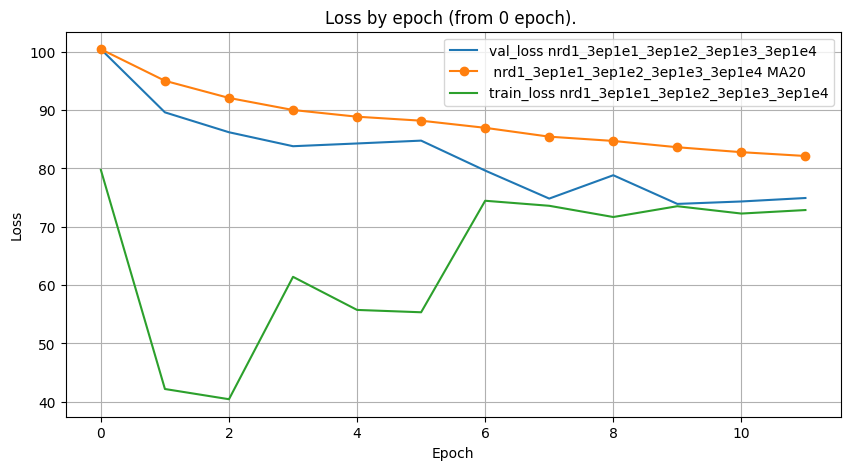

In [ ]:
TOTAL_NUM_EPOCHS = 600

if cfg['mode_train']:

    #
    plt.figure(figsize=(10,5))

    start_epoch = 0
    end_epoch = TOTAL_NUM_EPOCHS
    window = 20


    for i in range(len(net_curves_list[:])):
        net_curves = net_curves_list[i]
        name = curve_list[i].name

        metric = 'val_loss'

        plt.plot(
            net_curves["epoch"][start_epoch:end_epoch],
            net_curves[metric][start_epoch:end_epoch],
            label=f'{metric} {name}')

        loss_moving_average = pd.Series(
            net_curves[metric]
        ).rolling(window=window, min_periods=1).mean().tolist()
        plt.plot(
                net_curves["epoch"][start_epoch:end_epoch],
                loss_moving_average[start_epoch:end_epoch], 'o-',
                label = f" {name} MA{window}"
                )

        metric = 'train_loss'
        plt.plot(
            net_curves["epoch"][start_epoch:end_epoch],
            net_curves[metric][start_epoch:end_epoch],
            label=f'{metric} {name}')


    plt.title(f'Loss by epoch (from {start_epoch} epoch). ')
    plt.xlabel("Epoch")
    plt.ylabel(f"Loss")
    plt.legend()
    plt.grid()
    plt.show()

In [ ]:
net_curves_list[0]['epoch_displacement']

[nan,
 nan,
 nan,
 156.3263702392578,
 152.9744110107422,
 158.37538146972656,
 nan,
 nan,
 nan,
 48.36980056762695,
 2.687875747680664,
 2.7066361904144287]

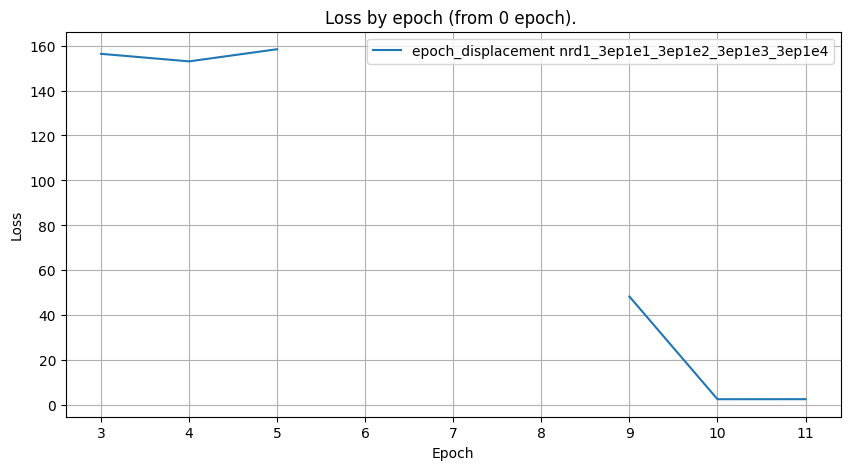

In [ ]:
TOTAL_NUM_EPOCHS = 600

if cfg['mode_train']:

    #
    plt.figure(figsize=(10,5))

    start_epoch = 0
    end_epoch = TOTAL_NUM_EPOCHS
    window = 20


    for i in range(len(net_curves_list[:])):
        net_curves = net_curves_list[i]
        name = curve_list[i].name

        metric = 'epoch_displacement'

        plt.plot(
            net_curves["epoch"][start_epoch:end_epoch],
            net_curves[metric][start_epoch:end_epoch],

            label=f'{metric} {name}')


    plt.title(f'Loss by epoch (from {start_epoch} epoch). ')
    plt.xlabel("Epoch")
    plt.ylabel(f"Loss")
    plt.legend()
    plt.grid()
    plt.show()

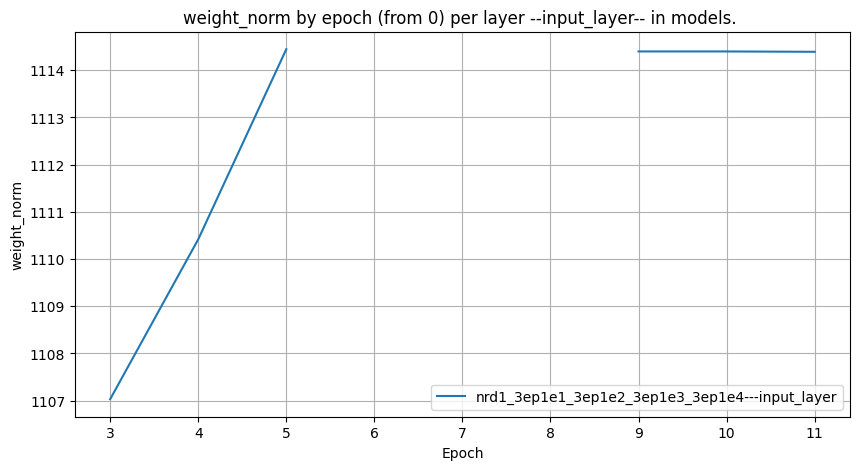

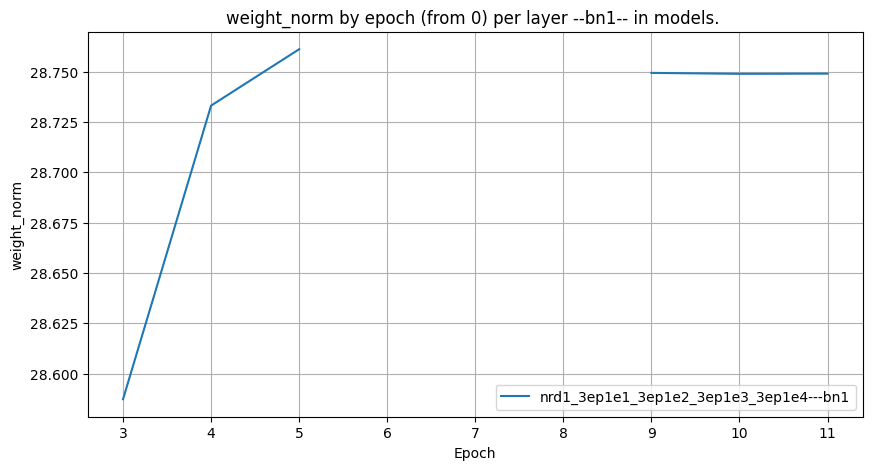

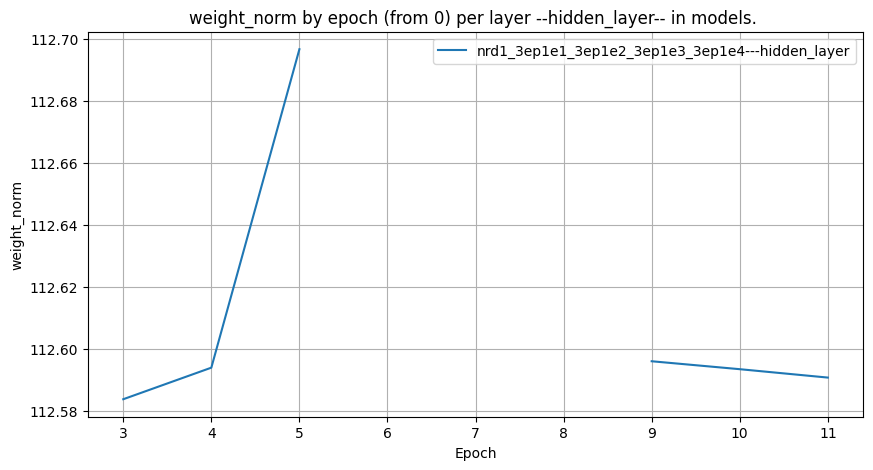

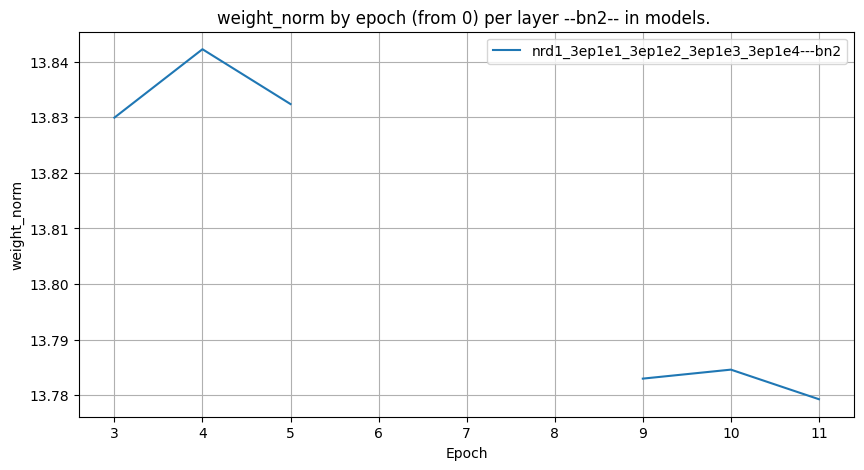

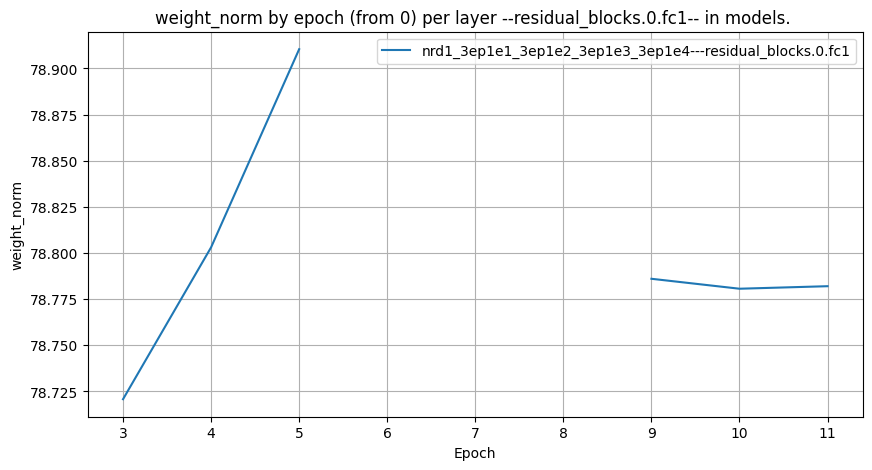

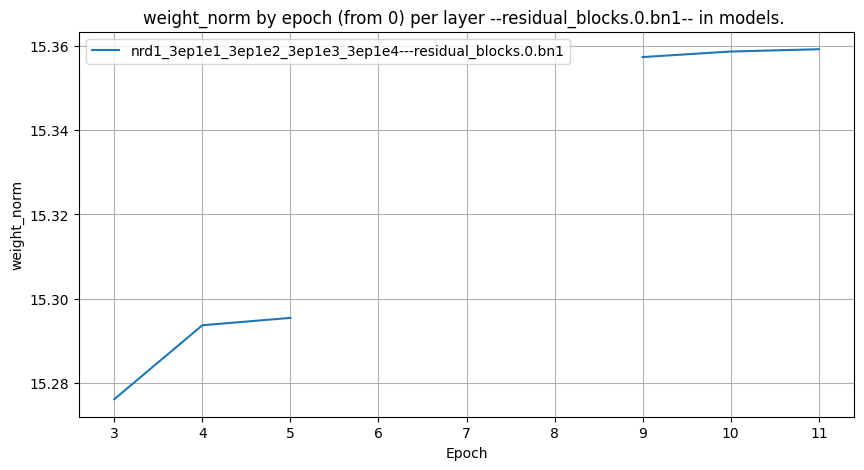

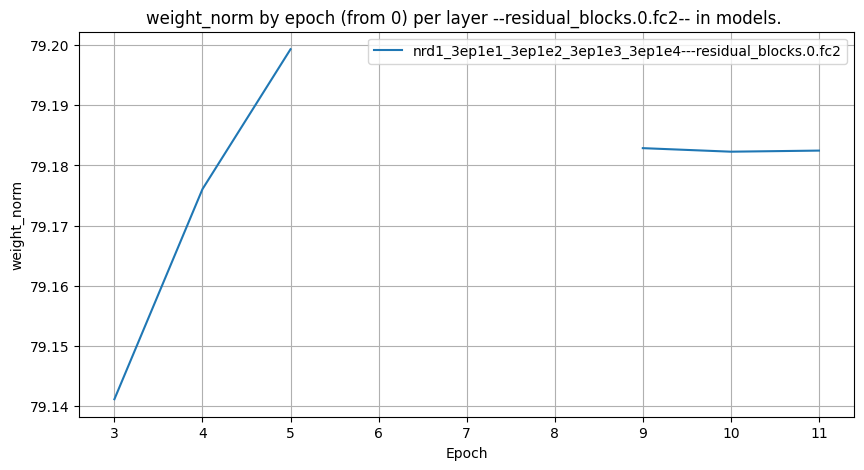

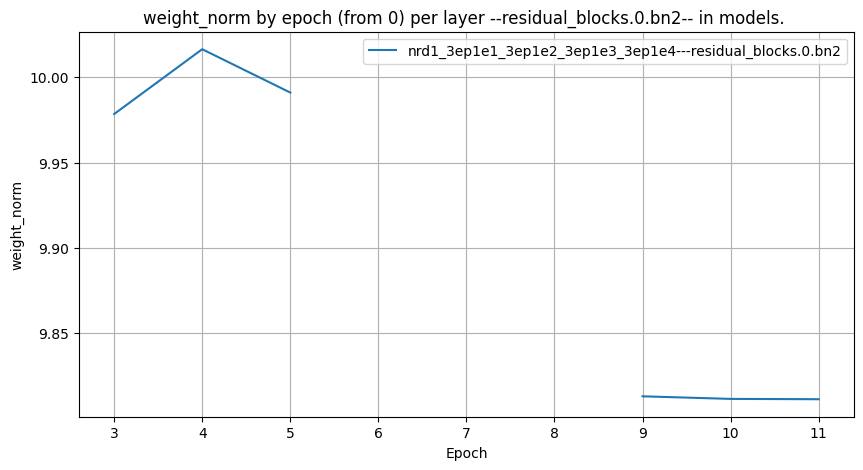

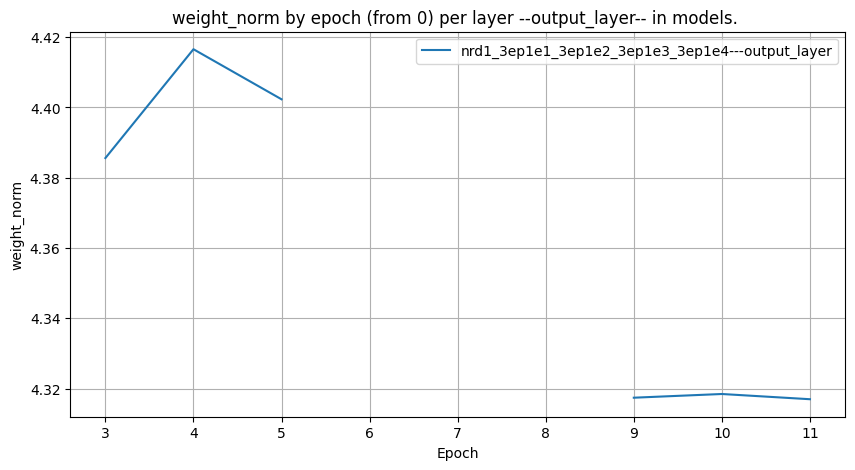

In [ ]:
if cfg['mode_train']:


    start_epoch = 0
    end_epoch = TOTAL_NUM_EPOCHS

    metric = "weight_norm"


    for layer in layers:
        plt.figure(figsize=(10,5))
        for i in range(len(layer_curves_list[:])):
            layer_curves = layer_curves_list[i]
            name = curve_list[i].name

            plt.plot(
                layer_curves[layer]["epoch"][start_epoch:end_epoch],
                layer_curves[layer][metric][start_epoch:end_epoch],
                label=f'{name}---{layer}'
            )


        plt.title(f'{metric} by epoch (from {start_epoch}) per layer --{layer}-- in models. ')
        plt.xlabel("Epoch")
        plt.ylabel(f"{metric}")
        plt.legend()
        plt.grid()
        plt.show()

In [ ]:
curve.checkpoints

[CheckpointInfo(epoch=2, file='ckpt_ResMLP_256-128x1_nrd1_3ep1e1_ep2.pth', val_loss=89.43678724016462, ma50=94.518336050851, train_loss=38.828083921160015, reason={}, is_best=False, train_walks='0M', train_time_str='0m8s', train_time=datetime.timedelta(seconds=8, microseconds=842198))]

In [ ]:
curve.net_metrics

[{'epoch': 0, 'train_loss': 79.84545333862305, 'val_loss': 97.28469839913504},
 {'epoch': 1, 'train_loss': 42.04156204223633, 'val_loss': 96.83352251325334},
 {'epoch': 2, 'train_loss': 38.828083921160015, 'val_loss': 89.43678724016462},
 {'epoch': 3,
  'train_loss': 60.347135598318914,
  'val_loss': 82.05030299595424,
  'epoch_displacement': 143.7166748046875,
  'relative_parameter_displacement': 0.12980103492736816,
  'cosine_update': nan,
  'update_variance': nan,
  'validation_improvement': nan,
  'improvement_per_displacement': nan},
 {'epoch': 4,
  'train_loss': 55.50876844133649,
  'val_loss': 84.4788223702567,
  'epoch_displacement': 140.96963500976562,
  'relative_parameter_displacement': 0.12696826457977295,
  'cosine_update': -0.033150143921375275,
  'update_variance': 1.8865569087211043,
  'validation_improvement': -2.4285193743024536,
  'improvement_per_displacement': -0.017227251628580874},
 {'epoch': 5,
  'train_loss': 58.560619158063616,
  'val_loss': 89.56844861711775,

In [ ]:
curve.tracker

{'prev_params': tensor([0.5786, 0.6165, 0.6277,  ..., 0.4101, 0.4486, 1.1542], device='cuda:0'),
 'prev_update': tensor([ 4.0832e-03, -4.4624e-03, -7.1537e-03,  ...,  0.0000e+00,
         -2.4438e-06,  1.3507e-02], device='cuda:0'),
 'update_norm_history': [153.08999633789062,
  147.15924072265625,
  151.6685791015625],
 'prev_val_loss': 84.38336342947824}

## test 2

In [ ]:
GROUPING_RULES = {


    "linear_layers_group":
        lambda name, m:
            isinstance(m, nn.Linear)
            and name != "output_layer",

    "output":
        lambda name, m:
            name == "output_layer",

    "bn1_group":
        lambda name, m:
            name.endswith(".bn1") or name == "bn1",

    "bn2_group":
        lambda name, m:
            name.endswith(".bn2") or name == "bn2",
}

GROUPING_NAMES = set(GROUPING_RULES.keys())

In [ ]:
print(GROUPING_RULES)
print(GROUPING_NAMES)

{'linear_layers_group': <function <lambda> at 0x7e17f8bc4fe0>, 'output': <function <lambda> at 0x7e17f8bc4cc0>, 'bn1_group': <function <lambda> at 0x7e17f8bc4d60>, 'bn2_group': <function <lambda> at 0x7e17f8bc49a0>}
{'bn2_group', 'bn1_group', 'linear_layers_group', 'output'}


In [ ]:
# test 2_1: broken curve

curve = Curve(

    num_epochs=10,

    cfg=cfg,

    group_names = GROUPING_NAMES,

)

assert curve.is_broken==True
print("OK")

manager = ExperimentManager(
    curve,
    graph,
    PilgrimAttnRes,
    GROUPING_RULES
)

assert manager.is_broken==True
print("OK")

manager.train(curve)

schedule is mandatory!!!
OK
curve is broken !!! -- > manager is broken !!!
OK
curve or manager is_broken!!! training did not start !!!


In [ ]:
# test 2_2 : schedule consistance

curve = Curve(

    schedule={"": {0:1e-2, 5:8e-3}},

    num_epochs=10,

    cfg=cfg,

    group_names = GROUPING_NAMES,

)

print(f"curve.name = {curve.name}")
assert curve.name=='nrd1_5ep1e2_5ep8e3', "curve.name mismatch"

print(f"curve.schedule == {curve.schedule}")
assert set(curve.schedule.keys())==curve.group_names, "layer group names missmath"

print(f"curve.threshold_epochs = {curve.threshold_epochs}")
assert curve.threshold_epochs==[9]
assert curve.threshold_val_losses==[]
assert curve.threshold_ma50s==[]
assert curve.total_num_epochs==0
print("OK")

curve.name = nrd1_5ep1e2_5ep8e3
curve.schedule == {'bn2_group': {0: 0.01, 5: 0.008}, 'bn1_group': {0: 0.01, 5: 0.008}, 'linear_layers_group': {0: 0.01, 5: 0.008}, 'output': {0: 0.01, 5: 0.008}}
curve.threshold_epochs = [9]
OK


In [ ]:
manager = ExperimentManager(
    curve,
    graph,
    PilgrimAttnRes,
    GROUPING_RULES
)

print(manager.groups.keys())
assert set(manager.groups.keys()) == set(GROUPING_NAMES)
print("OK")

dict_keys(['linear_layers_group', 'bn1_group', 'bn2_group', 'output'])
OK


In [ ]:
manager.train(curve)


Training nrd1_5ep1e2_5ep8e3

Epoch 0. Switch LR.
linear_layers_group       lr -> 0.01
bn1_group                 lr -> 0.01
bn2_group                 lr -> 0.01
output                    lr -> 0.01

Epoch 0
NET METRICS
Train Loss: 135.139 | Val Loss: 97.579 | MA50 Val Loss: 97.579 | 
epoch_displacement=119.128 | relative_parameter_displacement=4.0745 | cosine_update=nan | 
update_variance=nan | validation_improvement=nan | improvement_per_displacement=nan | 
LAYER METRICS
                       | grad=   21.500 | weight=  122.861 | g/w=  0.174995 | adam up= 3.750180 | a/w=  0.030524 | 
input_layer            | grad=    9.038 | weight=  116.580 | g/w=  0.077528 | adam up= 3.724273 | a/w=  0.031946 | 
bn1                    | grad=    2.243 | weight=   16.345 | g/w=  0.137218 | adam up= 0.121642 | a/w=  0.007442 | 
hidden_layer           | grad=    3.995 | weight=   17.992 | g/w=  0.222058 | adam up= 0.325912 | a/w=  0.018114 | 
bn2                    | grad=    2.892 | weight=   12.995 

In [ ]:
assert curve.total_num_epochs==10
assert curve.save_best==False
assert curve.saved_th_ma50s==set()
assert curve.saved_th_val_losses==set()
assert len(curve.checkpoints)==len(curve.threshold_epochs)
print("OK")

OK


In [ ]:
curve.checkpoints

[CheckpointInfo(epoch=9, file='ckpt_ResMLP_256-128x1_nrd1_5ep1e2_5ep8e3_ep9.pth', val_loss=84.00766270228794, ma50=84.997190889631, train_loss=28.784671363830565, reason={'th_epoch'}, is_best=False, train_walks='1M', train_time_str='0m29s', train_time=datetime.timedelta(seconds=29, microseconds=101334))]

In [ ]:
curve_loaded = Curve.load("curve_nrd1_5ep1e2_5ep8e3_ep9.pkl")

In [ ]:
curve1 = curve_loaded.clone()
curve2 = curve_loaded.clone()
curve3 = curve_loaded.clone()

In [ ]:
assert curve1.name=='nrd1_5ep1e2_5ep8e3'
assert curve1.ckpt_from=="ckpt_ResMLP_256-128x1_nrd1_5ep1e2_5ep8e3_ep9.pth"
assert curve1.total_num_epochs==10
assert curve1.save_best==False
assert curve1.saved_th_ma50s==set()
assert curve1.saved_th_val_losses==set()
assert len(curve1.checkpoints)==len(curve1.threshold_epochs)
print("OK")

OK


In [ ]:
curve1.extend(
    schedule={"": {0:6e-4, 5:5e-4}},
    num_epochs=10,
)

curve2.extend(
    schedule={"": {0:2e-4}},
    num_epochs=10,
)

curve3.extend(
    schedule={
        "linear_layers_group": {0:6e-4},

        "bn1_group": {0:5e-4},
        "bn2_group": {0:4e-4},

        "output": {0:3e-4},
        },
    num_epochs=10,
)

In [ ]:
assert curve1.name=='nrd1_5ep1e2_5ep8e3_5ep6e4_5ep5e4'
assert curve1.ckpt_from=="ckpt_ResMLP_256-128x1_nrd1_5ep1e2_5ep8e3_ep9.pth"
assert curve1.total_num_epochs==10
assert curve1.save_best==False
assert curve1.saved_th_ma50s==set()
assert curve1.saved_th_val_losses==set()
assert curve1.threshold_epochs==[9, 19]
assert curve1.schedule=={
    'bn2_group': {0: 0.01, 5: 0.008, 10: 0.0006, 15: 0.0005},
    'linear_layers_group': {0: 0.01, 5: 0.008, 10: 0.0006, 15: 0.0005},
    'output': {0: 0.01, 5: 0.008, 10: 0.0006, 15: 0.0005},
    'bn1_group': {0: 0.01, 5: 0.008, 10: 0.0006, 15: 0.0005}
    }
print("OK")

OK


In [ ]:
assert curve2.name=='nrd1_5ep1e2_5ep8e3_10ep2e4'
assert curve2.ckpt_from=="ckpt_ResMLP_256-128x1_nrd1_5ep1e2_5ep8e3_ep9.pth"
assert curve2.total_num_epochs==10
assert curve2.save_best==False
assert curve2.saved_th_ma50s==set()
assert curve2.saved_th_val_losses==set()
assert curve2.threshold_epochs==[9, 19]
assert curve2.schedule=={
    'bn2_group': {0: 0.01, 5: 0.008, 10: 0.0002},
    'linear_layers_group': {0: 0.01, 5: 0.008, 10: 0.0002},
    'output': {0: 0.01, 5: 0.008, 10: 0.0002},
    'bn1_group': {0: 0.01, 5: 0.008, 10: 0.0002}
    }
print("OK")

OK


In [ ]:
assert curve3.name=='nrd1_5ep1e2_5ep8e3_10ep-multi_lr'
assert curve3.ckpt_from=="ckpt_ResMLP_256-128x1_nrd1_5ep1e2_5ep8e3_ep9.pth"
assert curve3.total_num_epochs==10
assert curve3.save_best==False
assert curve3.saved_th_ma50s==set()
assert curve3.saved_th_val_losses==set()
assert curve3.threshold_epochs==[9, 19]
assert curve3.schedule=={
    'bn2_group': {0: 0.01, 5: 0.008, 10: 0.0004},
    'linear_layers_group': {0: 0.01, 5: 0.008, 10: 0.0006},
    'output': {0: 0.01, 5: 0.008, 10: 0.0003},
    'bn1_group': {0: 0.01, 5: 0.008, 10: 0.0005}
    }
print("OK")

OK


In [ ]:
# test 2_3 multi lr
curve = Curve(
    schedule={
        # "": {0:1e-2, 5:8e-3},

        "linear_layers_group": {0:5e-3, 5: 1e-3},
        "bn1_group": {0: 8e-3, 10: 4e-3, 25: 1e-3},
        "bn2_group": {0: 8e-3, 10: 4e-3, 25: 1e-3},
        "output": {0: 1e-2, 10: 6e-3, 30: 1e-3},
        },

    num_epochs=50,

    cfg=cfg,

    group_names = GROUPING_NAMES,

    save_best=True,

    threshold_epochs = [29, 49], # use idxes!

)

In [ ]:
print(f"curve.name = {curve.name}")
assert curve.name=='nrd1_50ep-multi_lr', "curve.name mismatch"

print(f"curve.schedule == {curve.schedule}")
assert set(curve.schedule.keys())==curve.group_names, "layer group names missmath"

print(f"curve.threshold_epochs = {curve.threshold_epochs}")
assert curve.threshold_epochs==[29, 49]
assert curve.threshold_val_losses==[]
assert curve.threshold_ma50s==[]
assert curve.total_num_epochs==0

print("OK")

curve.name = nrd1_50ep-multi_lr
curve.schedule == {'linear_layers_group': {0: 0.005, 5: 0.001}, 'bn1_group': {0: 0.008, 10: 0.004, 25: 0.001}, 'bn2_group': {0: 0.008, 10: 0.004, 25: 0.001}, 'output': {0: 0.01, 10: 0.006, 30: 0.001}}
curve.threshold_epochs = [29, 49]
OK


In [ ]:
manager = ExperimentManager(
    curve,
    graph,
    PilgrimAttnRes,
    GROUPING_RULES
)

print(manager.groups.keys())
assert set(manager.groups.keys()) == set(GROUPING_NAMES)
print("OK")

dict_keys(['linear_layers_group', 'bn1_group', 'bn2_group', 'output'])
OK


In [ ]:
manager.train(curve)


Training nrd1_50ep-multi_lr

Epoch 0. Switch LR.
linear_layers_group       lr -> 0.005
bn1_group                 lr -> 0.008
bn2_group                 lr -> 0.008
output                    lr -> 0.01

Epoch 0
NET METRICS
Train Loss: 125.398 | Val Loss: 97.450 | MA50 Val Loss: 97.450 | 
epoch_displacement=64.593 | relative_parameter_displacement=2.2097 | cosine_update=nan | 
update_variance=nan | validation_improvement=nan | improvement_per_displacement=nan | 
LAYER METRICS
                       | grad=   26.085 | weight=   71.179 | g/w=  0.366473 | adam up= 1.889580 | a/w=  0.026547 | 
input_layer            | grad=   14.364 | weight=   63.445 | g/w=  0.226399 | adam up= 1.878691 | a/w=  0.029611 | 
bn1                    | grad=    1.763 | weight=   16.020 | g/w=  0.110076 | adam up= 0.086363 | a/w=  0.005391 | 
hidden_layer           | grad=    7.725 | weight=   11.331 | g/w=  0.681702 | adam up= 0.153193 | a/w=  0.013520 | 
bn2                    | grad=    3.682 | weight=   12.87

In [ ]:
curve.checkpoints

[CheckpointInfo(epoch=29, file='ckpt_ResMLP_256-128x1_nrd1_50ep-multi_lr_ep29.pth', val_loss=74.38037381853376, ma50=79.94268365987142, train_loss=36.05273186819894, reason={'th_epoch'}, is_best=False, train_walks='5M', train_time_str='1m29s', train_time=datetime.timedelta(seconds=89, microseconds=351333)),
 CheckpointInfo(epoch=27, file='ckpt_ResMLP_256-128x1_nrd1_50ep-multi_lr_ep27.pth', val_loss=73.76360863821847, ma50=80.24205335811692, train_loss=36.21260135105678, reason={'th_epoch'}, is_best=True, train_walks='5M', train_time_str='1m23s', train_time=datetime.timedelta(seconds=83, microseconds=83172)),
 CheckpointInfo(epoch=49, file='ckpt_ResMLP_256-128x1_nrd1_50ep-multi_lr_ep49.pth', val_loss=69.20833871023996, ma50=76.62658930751255, train_loss=34.7647545841762, reason={'th_epoch'}, is_best=False, train_walks='8M', train_time_str='2m29s', train_time=datetime.timedelta(seconds=149, microseconds=236954)),
 CheckpointInfo(epoch=37, file='ckpt_ResMLP_256-128x1_nrd1_50ep-multi_lr_ep

In [ ]:
curve_loaded = Curve.load("curve_nrd1_50ep-multi_lr_ep49.pkl")

In [ ]:
curve1 = curve_loaded.clone()

assert curve1.name=='nrd1_50ep-multi_lr'
assert curve1.ckpt_from=="ckpt_ResMLP_256-128x1_nrd1_50ep-multi_lr_ep49.pth"
assert curve1.total_num_epochs==50
assert curve1.save_best==True
assert curve1.saved_th_ma50s==set()
assert curve1.saved_th_val_losses==set()
assert curve1.threshold_epochs == [29, 49]
print("OK")

OK


In [ ]:
curve1.extend(
    schedule={"": {0:6e-4, 5:5e-4}},
    num_epochs=10,
)

In [ ]:
curve1.schedule

{'linear_layers_group': {0: 0.005, 5: 0.001, 50: 0.0006, 55: 0.0005},
 'bn1_group': {0: 0.008, 10: 0.004, 25: 0.001, 50: 0.0006, 55: 0.0005},
 'bn2_group': {0: 0.008, 10: 0.004, 25: 0.001, 50: 0.0006, 55: 0.0005},
 'output': {0: 0.01, 10: 0.006, 30: 0.001, 50: 0.0006, 55: 0.0005}}

In [ ]:
assert curve1.name=='nrd1_50ep-multi_lr_5ep6e4_5ep5e4'
assert curve1.ckpt_from=="ckpt_ResMLP_256-128x1_nrd1_50ep-multi_lr_ep49.pth"
assert curve1.total_num_epochs==50
assert curve1.save_best==True
assert curve1.saved_th_ma50s==set()
assert curve1.saved_th_val_losses==set()
assert curve1.threshold_epochs==[29, 49, 59]
assert curve1.schedule=={
    'linear_layers_group': {0: 0.005, 5: 0.001, 50: 0.0006, 55: 0.0005},
    'bn1_group': {0: 0.008, 10: 0.004, 25: 0.001, 50: 0.0006, 55: 0.0005},
    'bn2_group': {0: 0.008, 10: 0.004, 25: 0.001, 50: 0.0006, 55: 0.0005},
    'output': {0: 0.01, 10: 0.006, 30: 0.001, 50: 0.0006, 55: 0.0005}
    }
print("OK")

OK


In [ ]:
manager1 = ExperimentManager(
    curve1,
    graph,
    PilgrimAttnRes,
    GROUPING_RULES
)

print(manager1.groups.keys())
assert set(manager.groups.keys()) == set(GROUPING_NAMES)
print("OK")

dict_keys(['linear_layers_group', 'bn1_group', 'bn2_group', 'output'])
OK


# example of usage

In [ ]:
GROUPING_RULES = {

    "":
        lambda name, module: name == "",

}

GROUPING_NAMES = set(GROUPING_RULES.keys())

In [ ]:
# !!!
curve = Curve(

    schedule={"": {0:2e-2, 40: 1e-2, 150: 1e-3, 300: 1e-4}},

    num_epochs=400,

    cfg=cfg,

    group_names = GROUPING_NAMES,

    save_best=True,

    threshold_epochs= [39, 149, 299, 399], # use idxes!

    threshold_val_losses=[57, 52],
    threshold_ma50s=[60, 55],

)

In [ ]:
curve.schedule

{'': {0: 0.02, 40: 0.01, 150: 0.001, 300: 0.0001}}

In [ ]:
curve.total_train_time

datetime.timedelta(0)

In [ ]:
curve.group_names

{''}

In [ ]:
manager = ExperimentManager(
    curve,
    graph,
    PilgrimAttnRes,
    GROUPING_RULES
)

In [ ]:
curve.checkpoints

[]

In [ ]:
manager.train(curve)


Training nrd1_40ep2e2_110ep1e2_150ep1e3_100ep1e4

Epoch 0. Switch LR.
                          lr -> 0.02

Epoch 0
NET METRICS
Train Loss: 93.460 | Val Loss: 100.065 | MA50 Val Loss: 100.065 | 
epoch_displacement=211.391 | relative_parameter_displacement=7.2296 | cosine_update=nan | 
update_variance=nan | validation_improvement=nan | improvement_per_displacement=nan | 
LAYER METRICS
                       | grad=   11.578 | weight=  213.441 | g/w=  0.054246 | adam up= 6.220493 | a/w=  0.029144 | 
input_layer            | grad=    5.254 | weight=  207.503 | g/w=  0.025321 | adam up= 6.192569 | a/w=  0.029843 | 
bn1                    | grad=    2.576 | weight=   16.972 | g/w=  0.151775 | adam up= 0.217503 | a/w=  0.012815 | 
hidden_layer           | grad=    2.672 | weight=   27.739 | g/w=  0.096328 | adam up= 0.492219 | a/w=  0.017745 | 
bn2                    | grad=    2.643 | weight=   12.296 | g/w=  0.214949 | adam up= 0.045225 | a/w=  0.003678 | 
residual_blocks        | grad=  

In [ ]:
curve.save_metrics_to_csv()

In [ ]:
print(curve.__dict__.keys())

dict_keys(['cfg', 'group_names', 'num_epochs', 'is_broken', 'total_train_time', 'total_num_epochs', 'schedule', 'name', 'current_epoch', 'ckpt_from', 'checkpoints', 'net_metrics', 'layer_metrics', 'tracker', 'save_best', 'threshold_epochs', 'threshold_val_losses', 'threshold_ma50s', 'saved_th_val_losses', 'saved_th_ma50s'])


In [ ]:
curve.name

'nrd1_40ep2e2_110ep1e2_150ep1e3_100ep1e4'

In [ ]:
curve.checkpoints

[CheckpointInfo(epoch=39, file='ckpt_ResMLP_256-128x1_nrd1_40ep2e2_110ep1e2_150ep1e3_100ep1e4_ep39.pth', val_loss=79.2983582850865, train_loss=31.90024052756173, reason={'th_epoch'}, is_best=False, train_walks='7M', train_time=datetime.timedelta(seconds=126, microseconds=417776)),
 CheckpointInfo(epoch=28, file='ckpt_ResMLP_256-128x1_nrd1_40ep2e2_110ep1e2_150ep1e3_100ep1e4_ep28.pth', val_loss=69.74402335030692, train_loss=29.630576248168946, reason={'th_epoch'}, is_best=True, train_walks='7M', train_time=datetime.timedelta(seconds=91, microseconds=632049)),
 CheckpointInfo(epoch=149, file='ckpt_ResMLP_256-128x1_nrd1_40ep2e2_110ep1e2_150ep1e3_100ep1e4_ep149.pth', val_loss=67.1166051374163, train_loss=34.80840517316546, reason={'th_epoch'}, is_best=False, train_walks='26M', train_time=datetime.timedelta(seconds=596, microseconds=227859)),
 CheckpointInfo(epoch=122, file='ckpt_ResMLP_256-128x1_nrd1_40ep2e2_110ep1e2_150ep1e3_100ep1e4_ep122.pth', val_loss=62.286438620431085, train_loss=36.1

In [ ]:
curve.total_num_epochs

400

In [ ]:
curve.net_metrics[-1]

{'epoch': 399,
 'train_loss': 54.62387069702149,
 'val_loss': 53.52735127040318,
 'epoch_displacement': 5.068453311920166,
 'relative_parameter_displacement': 0.0020332427229732275,
 'cosine_update': 0.05438588559627533,
 'update_variance': 0.014539728668094085,
 'validation_improvement': -2.29376325334821,
 'improvement_per_displacement': -0.45255684765867427}

In [ ]:
curve.layer_metrics[-1]

{'': {'epoch': 399,
  'grad_norm': 22.540830419935965,
  'weight_norm': 2492.788854085134,
  'grad_weight_ratio': 0.009042414636521051,
  'adam_update_norm': 0.04052384348355713,
  'update_weight_ratio': 1.625642838427628e-05},
 'input_layer': {'epoch': 399,
  'grad_norm': 1.2162625789642336,
  'weight_norm': 2467.2076015732164,
  'grad_weight_ratio': 0.000492971316312694,
  'adam_update_norm': 0.040099399938317674,
  'update_weight_ratio': 1.6252949250297483e-05},
 'bn1': {'epoch': 399,
  'grad_norm': 1.534440732022772,
  'weight_norm': 55.52497153996452,
  'grad_weight_ratio': 0.027635146664025195,
  'adam_update_norm': 0.0008719170979206675,
  'update_weight_ratio': 1.5703152540890233e-05},
 'hidden_layer': {'epoch': 399,
  'grad_norm': 0.5338484048843385,
  'weight_norm': 285.5358809055751,
  'grad_weight_ratio': 0.0018696368498110991,
  'adam_update_norm': 0.004884889177364351,
  'update_weight_ratio': 1.710779451560323e-05},
 'bn2': {'epoch': 399,
  'grad_norm': 7.102163975464904

In [ ]:
net_curves = curve.build_curves_per_net(curve.net_metrics)

In [ ]:
layer_curves = curve.build_curves_per_layer(curve.layer_metrics)

In [ ]:
# net_curves["epoch"]

In [ ]:
# layer_curves['output_layer']["epoch"]

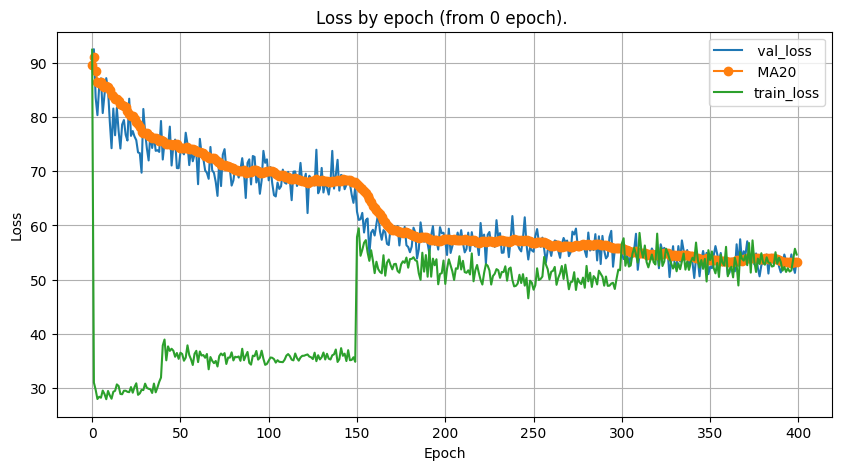

In [ ]:
if cfg['mode_train']:

    #
    plt.figure(figsize=(10,5))

    start_epoch = 0
    end_epoch = 400
    window = 20

    # for name in names[:-2]:
    #     net_curves = exp_net_curves[name]

    metric = 'val_loss'
    plt.plot(
        net_curves["epoch"][start_epoch:end_epoch],
        net_curves[metric][start_epoch:end_epoch],
        label=f' {metric}')

    loss_moving_average = pd.Series(
        net_curves[metric][start_epoch:end_epoch]
    ).rolling(window=window, min_periods=1).mean().tolist()
    # paper_dict["loss"] = f"{loss_moving_average[-1]:.1f}"   ### !!!
    plt.plot(
            net_curves["epoch"][start_epoch:end_epoch],
            loss_moving_average, 'o-',
            label = f" MA20"
            )

    metric = 'train_loss'
    plt.plot(net_curves["epoch"][start_epoch:], net_curves[metric][start_epoch:], label=f'{metric}')




    plt.title(f'Loss by epoch (from {start_epoch} epoch). ')
    plt.xlabel("Epoch")
    plt.ylabel(f"Loss")
    plt.legend()
    plt.grid()
    plt.show()

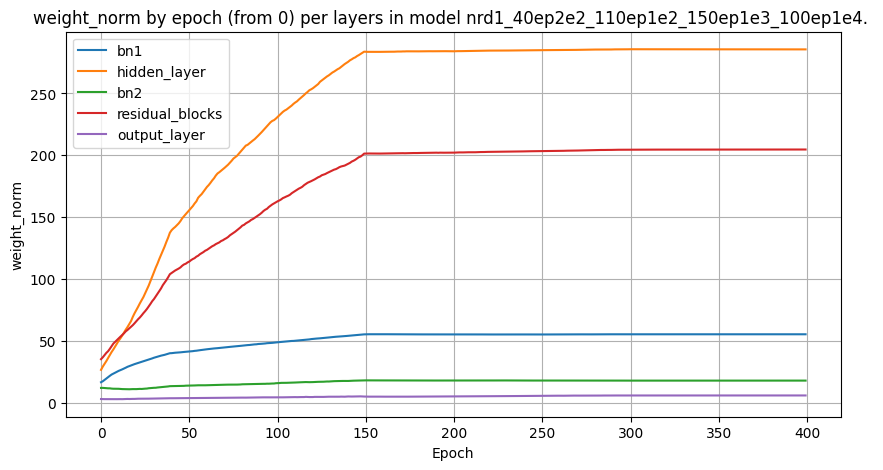

In [ ]:
# weight_norm for layers

if cfg['mode_train']:

    plt.figure(figsize=(10,5))

    start_epoch = 0

    layers = [
        # '',
        # 'input_layer',
        'bn1',
        'hidden_layer',
        'bn2',
        'residual_blocks',
        # 'residual_blocks.0',
        # 'residual_blocks.0.fc1',
        # 'residual_blocks.0.bn1',
        # 'residual_blocks.0.fc2',
        # 'residual_blocks.0.bn2',
        'output_layer'
        ]

    metric = "weight_norm"

    for curve in [curve]:
        for layer in layers:
            # layer_curves = exp_layer_curves[name]
            layer_curves = curve.build_curves_per_layer(curve.layer_metrics)
            plt.plot(
                layer_curves[layer]["epoch"][start_epoch:],
                layer_curves[layer][metric][start_epoch:],
                label=f'{layer}'
            )

    plt.title(f'{metric} by epoch (from {start_epoch}) per layers in model {curve.name}. ')
    plt.xlabel("Epoch")
    plt.ylabel(f"{metric}")
    plt.legend()
    plt.grid()
    plt.show()

# ex 0: best sw_epoch finding

In [ ]:
GROUPING_RULES = {

    "":
        lambda name, module: name == "",

}

GROUPING_NAMES = set(GROUPING_RULES.keys())

In [ ]:
# 50 = 50
NUM_EPOCHS = 50

curve1 = Curve(

    schedule={"": {0:1e-2}},

    num_epochs=NUM_EPOCHS,

    cfg=cfg,

    group_names = GROUPING_NAMES,

)

curve_list = [curve1]

for curve in curve_list:
    manager = ExperimentManager(
                              curve,
                              graph,
                              PilgrimAttnRes,
                              GROUPING_RULES
                                        )
    manager.train(curve)

#####################################################
# 50 + 50 =100
curve2 = curve1.clone()

NUM_EPOCHS = 50

#-------------------------
curve1.extend(
    num_epochs=NUM_EPOCHS,
)

curve2.extend(
    schedule={"": {0:1e-3}},
    num_epochs=NUM_EPOCHS,
)

curve_list = [curve1, curve2]

# TRAIN!

for curve in curve_list:
    manager = ExperimentManager(
                              curve,
                              graph,
                              PilgrimAttnRes,
                              GROUPING_RULES
                                        )
    manager.train(curve)
    # curve.save_metrics_to_csv()
    # curve.archive_metrics()

#####################################################
# 50 + 50 + 30 = 130

curve3 = curve1.clone()

NUM_EPOCHS = 30

#-------------------------
curve1.extend(
    num_epochs=NUM_EPOCHS,
)

curve2.extend(
    num_epochs=NUM_EPOCHS,
)

curve3.extend(
    schedule={"": {0:1e-3}},
    num_epochs=NUM_EPOCHS,
)

curve_list = [curve1, curve2, curve3]

# TRAIN!

for curve in curve_list:
    manager = ExperimentManager(
                              curve,
                              graph,
                              PilgrimAttnRes,
                              GROUPING_RULES
                                        )
    manager.train(curve)
    # curve.save_metrics_to_csv()
    # curve.archive_metrics()

#####################################################
# 50 + 50 + 30 + 20 = 150

curve4 = curve1.clone()

NUM_EPOCHS = 20

#-------------------------
curve1.extend(
    num_epochs=NUM_EPOCHS,
)

curve2.extend(
    num_epochs=NUM_EPOCHS,
)

curve3.extend(
    num_epochs=NUM_EPOCHS,
)

curve4.extend(
    schedule={"": {0:1e-3}},
    num_epochs=NUM_EPOCHS,
)

curve_list = [curve1, curve2, curve3, curve4]

# TRAIN!

for curve in curve_list:
    manager = ExperimentManager(
                              curve,
                              graph,
                              PilgrimAttnRes,
                              GROUPING_RULES
                                        )
    manager.train(curve)
    # curve.save_metrics_to_csv()
    # curve.archive_metrics()

#####################################################
# 50 + 50 + 30 + 20 + 150 = 300

curve5 = curve1.clone()

NUM_EPOCHS = 150

#-------------------------
curve1.extend(
    num_epochs=NUM_EPOCHS,
)

curve2.extend(
    num_epochs=NUM_EPOCHS,
)

curve3.extend(
    num_epochs=NUM_EPOCHS,
)

curve4.extend(
    num_epochs=NUM_EPOCHS,
)

curve5.extend(
    schedule={"": {0:1e-3}},
    num_epochs=NUM_EPOCHS,
)

curve_list = [curve1, curve2, curve3, curve4, curve5]

# TRAIN!

for curve in curve_list:
    manager = ExperimentManager(
                              curve,
                              graph,
                              PilgrimAttnRes,
                              GROUPING_RULES
                                        )
    manager.train(curve)
    curve.save_metrics_to_csv()
    curve.archive_metrics()


Training nrd1_50ep1e2

Epoch 0. Switch LR.
                          lr -> 0.01

Epoch 0
NET METRICS
Train Loss: 118.431 | Val Loss: 95.553 | MA50 Val Loss: 95.553 | 
epoch_displacement=116.968 | relative_parameter_displacement=4.0013 | cosine_update=nan | 
update_variance=nan | validation_improvement=nan | improvement_per_displacement=nan | 
LAYER METRICS
                       | grad=   53.683 | weight=  120.776 | g/w=  0.444485 | adam up= 3.606020 | a/w=  0.029857 | 
input_layer            | grad=    8.617 | weight=  114.786 | g/w=  0.075072 | adam up= 3.524469 | a/w=  0.030705 | 
bn1                    | grad=    2.518 | weight=   16.182 | g/w=  0.155598 | adam up= 0.141392 | a/w=  0.008737 | 
hidden_layer           | grad=    5.385 | weight=   16.550 | g/w=  0.325366 | adam up= 0.449291 | a/w=  0.027148 | 
bn2                    | grad=    8.271 | weight=   13.092 | g/w=  0.631801 | adam up= 0.053655 | a/w=  0.004098 | 
residual_blocks        | grad=   13.268 | weight=   26.375 |

In [ ]:
# to plot from curve imidiatly after training

curve_file_names_list = [curve.get_basic_file_name_for_curve() for curve in curve_list]
print(curve_file_names_list)

curve_loaded_list = [Curve.load(f_name) for f_name in curve_file_names_list]

net_curves_list = [curve.build_curves_per_net(curve.net_metrics) for curve in curve_loaded_list]

layer_curves_list = [curve.build_curves_per_layer(curve.layer_metrics) for curve in curve_loaded_list]

['curve_nrd1_50ep1e2_50ep_30ep_20ep_150ep_ep299.pkl', 'curve_nrd1_50ep1e2_50ep1e3_30ep_20ep_150ep_ep299.pkl', 'curve_nrd1_50ep1e2_50ep_30ep1e3_20ep_150ep_ep299.pkl', 'curve_nrd1_50ep1e2_50ep_30ep_20ep1e3_150ep_ep299.pkl', 'curve_nrd1_50ep1e2_50ep_30ep_20ep_150ep1e3_ep299.pkl']


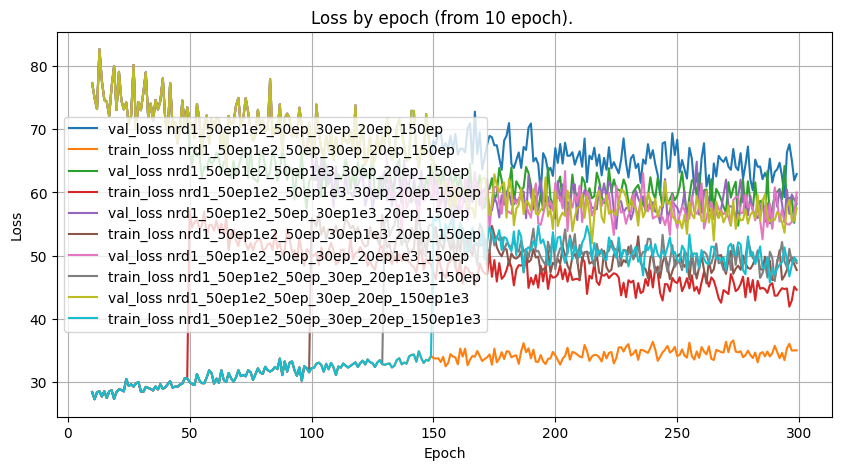

In [ ]:
TOTAL_NUM_EPOCHS = 600

if cfg['mode_train']:

    #
    plt.figure(figsize=(10,5))

    start_epoch = 10
    end_epoch = TOTAL_NUM_EPOCHS
    window = 20


    for i in range(len(net_curves_list[:])):
        net_curves = net_curves_list[i]
        name = curve_loaded_list[i].name

        metric = 'val_loss'

        plt.plot(
            net_curves["epoch"][start_epoch:end_epoch],
            net_curves[metric][start_epoch:end_epoch],
            label=f'{metric} {name}')

        # loss_moving_average = pd.Series(
        #     net_curves[metric]
        # ).rolling(window=window, min_periods=1).mean().tolist()
        # plt.plot(
        #         net_curves["epoch"][start_epoch:end_epoch],
        #         loss_moving_average[start_epoch:end_epoch], 'o-',
        #         label = f" {name} MA{window}"
        #         )

        metric = 'train_loss'
        plt.plot(
            net_curves["epoch"][start_epoch:end_epoch],
            net_curves[metric][start_epoch:end_epoch],
            label=f'{metric} {name}')


    plt.title(f'Loss by epoch (from {start_epoch} epoch). ')
    plt.xlabel("Epoch")
    plt.ylabel(f"Loss")
    plt.legend()
    plt.grid()
    plt.show()

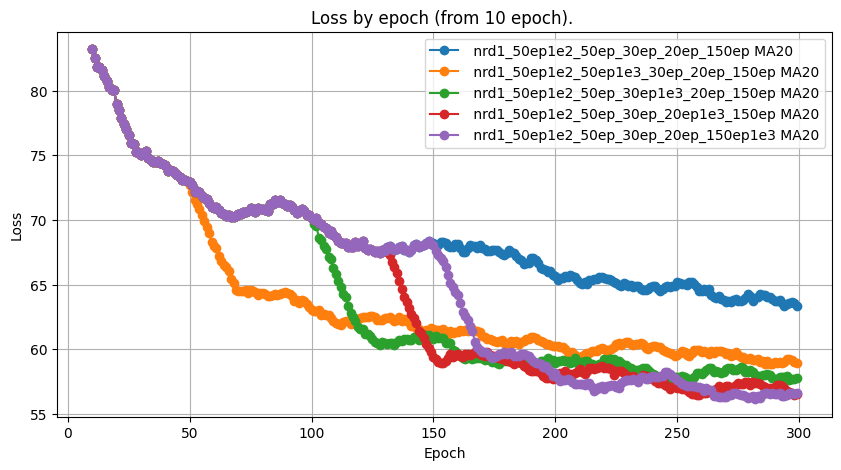

In [ ]:
TOTAL_NUM_EPOCHS = 600

if cfg['mode_train']:

    #
    plt.figure(figsize=(10,5))

    start_epoch = 10
    end_epoch = TOTAL_NUM_EPOCHS
    window = 20


    for i in range(len(net_curves_list[:])):
        net_curves = net_curves_list[i]
        name = curve_loaded_list[i].name

        metric = 'val_loss'

        # plt.plot(
        #     net_curves["epoch"][start_epoch:end_epoch],
        #     net_curves[metric][start_epoch:end_epoch],
        #     label=f'{metric} {name}')

        loss_moving_average = pd.Series(
            net_curves[metric]
        ).rolling(window=window, min_periods=1).mean().tolist()
        plt.plot(
                net_curves["epoch"][start_epoch:end_epoch],
                loss_moving_average[start_epoch:end_epoch], 'o-',
                label = f" {name} MA{window}"
                )

        # metric = 'train_loss'
        # plt.plot(
        #     net_curves["epoch"][start_epoch:end_epoch],
        #     net_curves[metric][start_epoch:end_epoch],
        #     label=f'{metric} {name}')


    plt.title(f'Loss by epoch (from {start_epoch} epoch). ')
    plt.xlabel("Epoch")
    plt.ylabel(f"Loss")
    plt.legend()
    plt.grid()
    plt.show()

# test min loss finding

In [ ]:
GROUPING_RULES = {

    "":
        lambda name, module: name == "",

}

GROUPING_NAMES = set(GROUPING_RULES.keys())

NUM_EPOCHS = 1

In [ ]:
result = dict()
lr_list = [1e-1, 8e-2]

result["lr"] = lr_list

num_runs = 3

In [ ]:
result_df = get_loss_per_lr_for0epoch(result, num_runs)
result_df

lr = 0.1
lr = 0.08


,lr,avg_val_loss,avg_train_loss,avg_epoch_,avg_grad_norm_,avg_weight_norm_,avg_grad_weight_ratio_,avg_adam_update_norm_,avg_update_weight_ratio_,avg_epoch_input_layer,...,avg_weight_norm_residual_blocks.0.bn2,avg_grad_weight_ratio_residual_blocks.0.bn2,avg_adam_update_norm_residual_blocks.0.bn2,avg_update_weight_ratio_residual_blocks.0.bn2,avg_epoch_output_layer,avg_grad_norm_output_layer,avg_weight_norm_output_layer,avg_grad_weight_ratio_output_layer,avg_adam_update_norm_output_layer,avg_update_weight_ratio_output_layer
0,0.10,98.817300,79.710657,0,17.133280,891.701605,0.019169,15.664503,0.017557,0,...,12.372195,0.508582,0.191632,0.015520,0,14.280399,5.063676,2.872804,0.088283,0.017612
1,0.08,97.305705,81.264525,0,18.132136,722.892035,0.025078,14.025393,0.019404,0,...,11.818162,0.425512,0.145032,0.012543,0,15.803262,4.442353,3.623494,0.065186,0.015101


In [ ]:
result_df[['lr', 'avg_val_loss', 'avg_train_loss']]

,lr,avg_val_loss,avg_train_loss
0,0.10,98.817300,79.710657
1,0.08,97.305705,81.264525


In [ ]:
lr_min = result_df["lr"][result_df["avg_val_loss"] == min(result_df["avg_val_loss"])]
lr_min.iloc[0]

np.float64(0.08)

In [ ]:
layers = [
        # '',
        'input_layer',
        'bn1',
        'hidden_layer',
        'bn2',
        'residual_blocks',
        # 'residual_blocks.0',
        # 'residual_blocks.0.fc1',
        # 'residual_blocks.0.bn1',
        # 'residual_blocks.0.fc2',
        # 'residual_blocks.0.bn2',
        # 'residual_blocks.1',
        # 'residual_blocks.1.fc1',
        # 'residual_blocks.1.bn1',
        # 'residual_blocks.1.fc2',
        # 'residual_blocks.1.bn2',
        'output_layer'
        ]


In [ ]:
metric = "grad_norm"

In [ ]:
col_list = [f"avg_{metric}_{layer}" for layer in layers]

In [ ]:
col_list = ["lr"] + col_list

In [ ]:
result_df[col_list]

,lr,avg_grad_norm_input_layer,avg_grad_norm_bn1,avg_grad_norm_hidden_layer,avg_grad_norm_bn2,avg_grad_norm_residual_blocks,avg_grad_norm_output_layer
0,0.10,1.722716,1.799551,0.864486,5.122869,6.784734,14.280399
1,0.08,2.029461,1.868083,1.004580,4.852539,5.557495,15.803262


# start_lr finding for nrd=1

In [ ]:
GROUPING_RULES = {

    "":
        lambda name, module: name == "",

}

GROUPING_NAMES = set(GROUPING_RULES.keys())

NUM_EPOCHS = 1

In [ ]:
result = dict()
lr_list = [1e-1, 8e-2, 6e-2, 4e-2, 2e-2, 1e-2, 8e-3, 6e-3, 4e-3, 2e-3, 1e-3]

result["lr"] = lr_list

num_runs = 20

In [ ]:
result_df = get_loss_per_lr_for0epoch(result, num_runs)
result_df.to_csv(f"nrd1__min_start_lr_1e1-1e3_df.csv", index=False)

lr = 0.1
lr = 0.08
lr = 0.06
lr = 0.04
lr = 0.02
lr = 0.01
lr = 0.008
lr = 0.006
lr = 0.004
lr = 0.002
lr = 0.001


In [ ]:
result_df

NameError: name 'result_df' is not defined

In [ ]:
layers = [
        # '',
        'input_layer',
        'bn1',
        'hidden_layer',
        'bn2',
        'residual_blocks',
        # 'residual_blocks.0',
        'residual_blocks.0.fc1',
        # 'residual_blocks.0.bn1',
        # 'residual_blocks.0.fc2',
        'residual_blocks.0.bn2',
        # 'residual_blocks.1',
        # 'residual_blocks.1.fc1',
        # 'residual_blocks.1.bn1',
        # 'residual_blocks.1.fc2',
        # 'residual_blocks.1.bn2',
        'output_layer'
        ]

In [ ]:
# metric = "grad_norm"
# metric = "weight_norm"

# metric ="grad_weight_ratio"

# metric ="adam_update_norm"
metric ="update_weight_ratio"

In [ ]:
col_list = [f"avg_{metric}_{layer}" for layer in layers]

In [ ]:
col_list = ["lr"] + col_list

In [ ]:
result_df[col_list]

,lr,avg_update_weight_ratio_input_layer,avg_update_weight_ratio_bn1,avg_update_weight_ratio_hidden_layer,avg_update_weight_ratio_bn2,avg_update_weight_ratio_residual_blocks,avg_update_weight_ratio_output_layer
0,0.100,0.017056,0.018971,0.009282,0.012801,0.005888,0.018080
1,0.080,0.019476,0.020395,0.009254,0.010606,0.005519,0.014958
2,0.060,0.022016,0.018853,0.009997,0.010188,0.005593,0.014734
3,0.040,0.026290,0.018192,0.012161,0.006927,0.007822,0.007856
4,0.020,0.030098,0.012983,0.017623,0.004385,0.010335,0.004675
5,0.010,0.031055,0.007293,0.017808,0.001935,0.008804,0.002486
6,0.008,0.030892,0.005978,0.017624,0.001475,0.007682,0.001963
7,0.006,0.030444,0.004738,0.017500,0.000992,0.008239,0.001268
8,0.004,0.030476,0.003382,0.016084,0.000694,0.006280,0.001015
9,0.002,0.030783,0.001902,0.013345,0.000329,0.004420,0.000428


In [ ]:
#############

In [ ]:
layers = [
        # '',
        'input_layer',
        'bn1',
        'hidden_layer',
        'bn2',
        'residual_blocks',
        # 'residual_blocks.0',
        'residual_blocks.0.fc1',
        # 'residual_blocks.0.bn1',
        # 'residual_blocks.0.fc2',
        'residual_blocks.0.bn2',
        # 'residual_blocks.1',
        # 'residual_blocks.1.fc1',
        # 'residual_blocks.1.bn1',
        # 'residual_blocks.1.fc2',
        # 'residual_blocks.1.bn2',
        'output_layer'
        ]

In [ ]:
metric = "grad_norm"
# metric = "weight_norm"

# metric ="grad_weight_ratio"

# metric ="adam_update_norm"
# metric ="update_weight_ratio"

print(f"metric = {metric}")

col_list = ["lr"] + [
    f"avg_{metric}_{layer}"
    for layer in layers
]

metric_df = result_df[col_list].rename(
    columns={
        f"avg_{metric}_{layer}": layer
        for layer in layers
    }
)

metric_df

metric = grad_norm


,lr,input_layer,bn1,hidden_layer,bn2,residual_blocks,residual_blocks.0.fc1,residual_blocks.0.bn2,output_layer
0,0.100,1.623553,2.000513,1.172694,9.164860,10.974290,1.214599,10.291883,31.093536
1,0.080,1.948978,1.796432,0.903307,5.275601,6.548252,0.731619,6.202295,18.225723
2,0.060,2.446678,2.104561,1.079731,6.550863,7.800447,0.950846,7.302771,23.191641
3,0.040,3.202240,2.141694,1.434881,4.031044,4.975799,1.425173,4.239331,15.333019
4,0.020,5.197907,2.291354,2.800562,3.951405,6.882417,3.915663,3.815606,16.378070
5,0.010,8.456152,2.102236,4.318860,4.182461,9.295806,6.371960,4.266711,24.111169
6,0.008,9.993904,2.025839,4.944152,3.940480,9.382117,6.921760,3.605299,23.393426
7,0.006,12.256980,2.053066,6.462346,3.643510,10.981920,8.582066,3.480820,23.998188
8,0.004,16.738775,1.917094,7.460459,3.205386,11.694482,9.764233,2.753927,20.743013
9,0.002,29.823182,2.069603,11.013957,3.863645,18.304481,16.108980,3.494185,28.548747


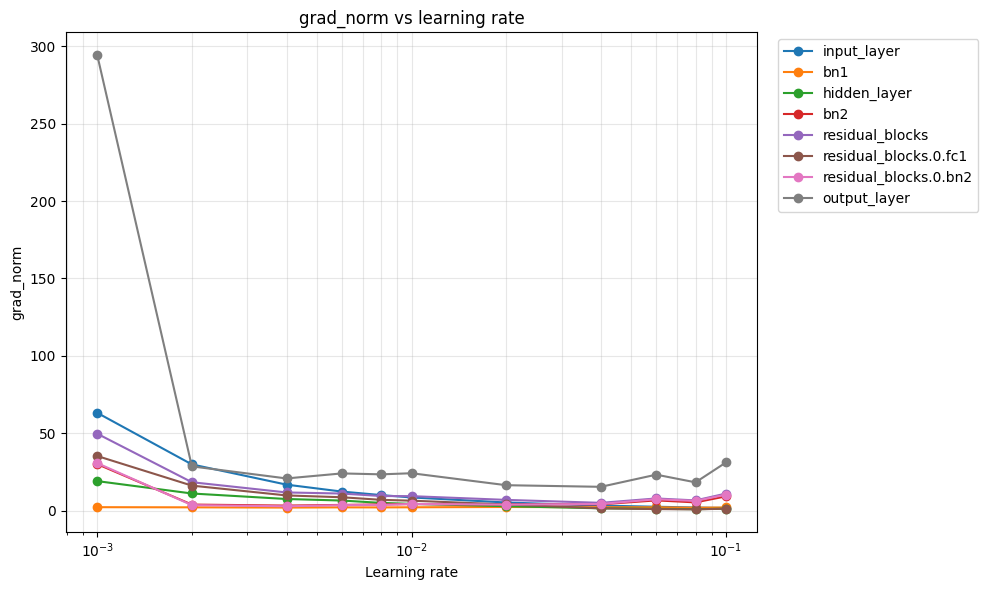

filename = nrd1_grad_norm.png


In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

for layer in layers:
    ax.plot(
        metric_df["lr"],
        metric_df[layer],
        marker="o",
        label=layer,
    )

ax.set_xscale("log")

ax.set_xlabel("Learning rate")
ax.set_ylabel(metric)
ax.set_title(f"{metric} vs learning rate")

ax.grid(True, which="both", alpha=0.3)
ax.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

plt.tight_layout()
plt.show()

save_fig(fig, f"nrd{cfg['nrd']}_{metric}.png")

In [ ]:
# metric = "grad_norm"
metric = "weight_norm"

# metric ="grad_weight_ratio"

# metric ="adam_update_norm"
# metric ="update_weight_ratio"

print(f"metric = {metric}")

col_list = ["lr"] + [
    f"avg_{metric}_{layer}"
    for layer in layers
]

metric_df = result_df[col_list].rename(
    columns={
        f"avg_{metric}_{layer}": layer
        for layer in layers
    }
)

metric_df

metric = weight_norm


,lr,input_layer,bn1,hidden_layer,bn2,residual_blocks,residual_blocks.0.fc1,residual_blocks.0.bn2,output_layer
0,0.100,874.159378,23.746801,106.935245,12.985107,111.595740,75.662759,10.898429,4.855526
1,0.080,709.079655,22.150233,86.656804,12.400346,91.480175,61.772930,11.347900,4.393391
2,0.060,543.922526,20.608647,66.337708,11.919303,72.733091,47.810452,11.539963,4.023127
3,0.040,377.473231,18.756266,46.076117,11.546097,54.191366,34.195033,12.013202,3.602881
4,0.020,206.785925,16.994454,26.889373,12.180185,35.520369,20.481431,12.950882,3.249856
5,0.010,115.439880,16.240559,17.073476,13.064866,26.259262,13.297511,13.332718,2.873654
6,0.008,96.515987,16.111467,15.177593,13.242238,24.728639,11.990718,13.426668,2.761701
7,0.006,75.922771,15.994330,13.053283,13.414990,23.298525,10.490932,13.542126,2.654223
8,0.004,54.092036,15.905043,10.907413,13.578082,21.958200,8.969991,13.651128,2.534894
9,0.002,31.243688,15.857236,8.831341,13.731808,21.014308,7.747981,13.787954,2.403239


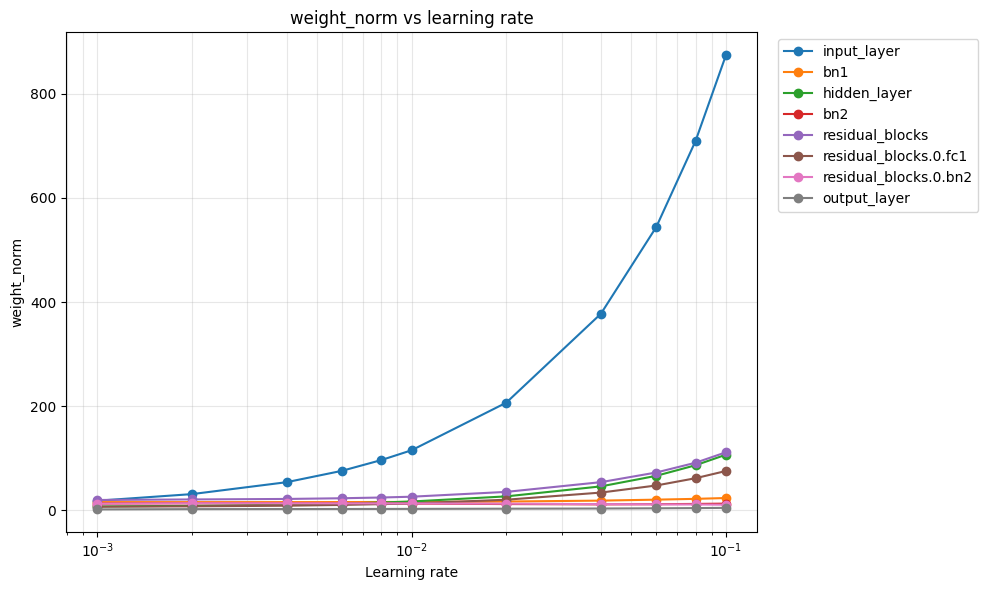

filename = nrd1_weight_norm.png


In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

for layer in layers:
    ax.plot(
        metric_df["lr"],
        metric_df[layer],
        marker="o",
        label=layer,
    )

ax.set_xscale("log")

ax.set_xlabel("Learning rate")
ax.set_ylabel(metric)
ax.set_title(f"{metric} vs learning rate")

ax.grid(True, which="both", alpha=0.3)
ax.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

plt.tight_layout()
plt.show()

save_fig(fig, f"nrd{cfg['nrd']}_{metric}.png")

In [ ]:
# metric = "grad_norm"
# metric = "weight_norm"

metric ="grad_weight_ratio"

# metric ="adam_update_norm"
# metric ="update_weight_ratio"

print(f"metric = {metric}")

col_list = ["lr"] + [
    f"avg_{metric}_{layer}"
    for layer in layers
]

metric_df = result_df[col_list].rename(
    columns={
        f"avg_{metric}_{layer}": layer
        for layer in layers
    }
)

metric_df

metric = grad_weight_ratio


,lr,input_layer,bn1,hidden_layer,bn2,residual_blocks,residual_blocks.0.fc1,residual_blocks.0.bn2,output_layer
0,0.100,0.001857,0.084175,0.010958,0.704843,0.097988,0.016083,0.953150,6.422705
1,0.080,0.002748,0.080992,0.010419,0.425141,0.071763,0.011858,0.551559,4.161359
2,0.060,0.004498,0.102065,0.016259,0.547507,0.107567,0.019874,0.633002,5.782943
3,0.040,0.008484,0.114232,0.031169,0.348658,0.092031,0.041816,0.352858,4.270210
4,0.020,0.025140,0.134926,0.103920,0.324411,0.193645,0.191146,0.294330,5.040273
5,0.010,0.073252,0.129453,0.252692,0.319732,0.354069,0.479146,0.320044,8.405624
6,0.008,0.103607,0.125776,0.326791,0.297364,0.380375,0.582132,0.268306,8.458858
7,0.006,0.161467,0.128376,0.495734,0.271687,0.470860,0.817074,0.257029,9.035301
8,0.004,0.309474,0.120541,0.684387,0.236026,0.532204,1.086217,0.201775,8.186896
9,0.002,0.954699,0.130523,1.248310,0.281185,0.871191,2.081876,0.253270,11.909323


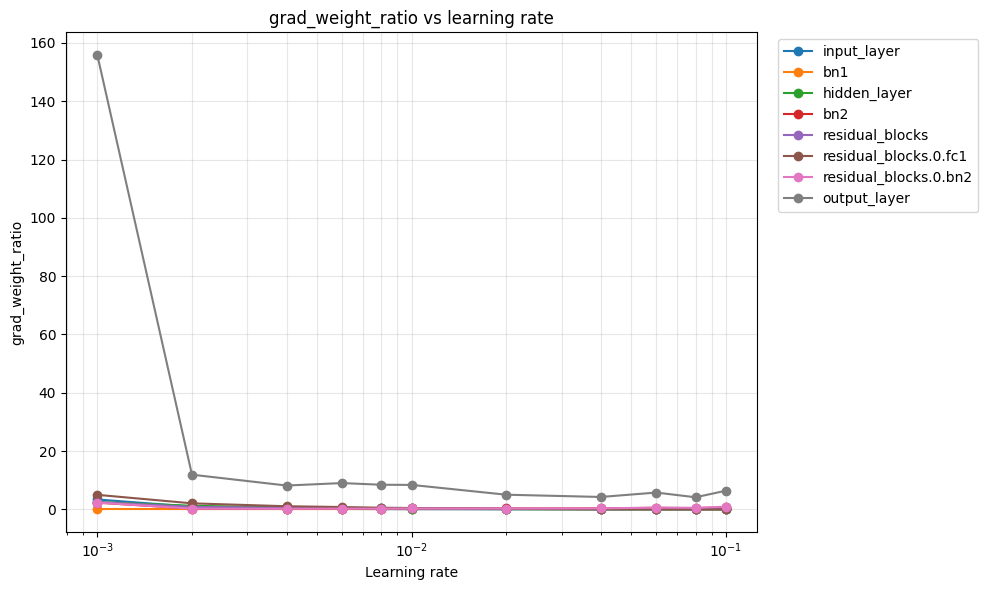

filename = nrd1_grad_weight_ratio.png


In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

for layer in layers:
    ax.plot(
        metric_df["lr"],
        metric_df[layer],
        marker="o",
        label=layer,
    )

ax.set_xscale("log")

ax.set_xlabel("Learning rate")
ax.set_ylabel(metric)
ax.set_title(f"{metric} vs learning rate")

ax.grid(True, which="both", alpha=0.3)
ax.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

plt.tight_layout()
plt.show()

save_fig(fig, f"nrd{cfg['nrd']}_{metric}.png")

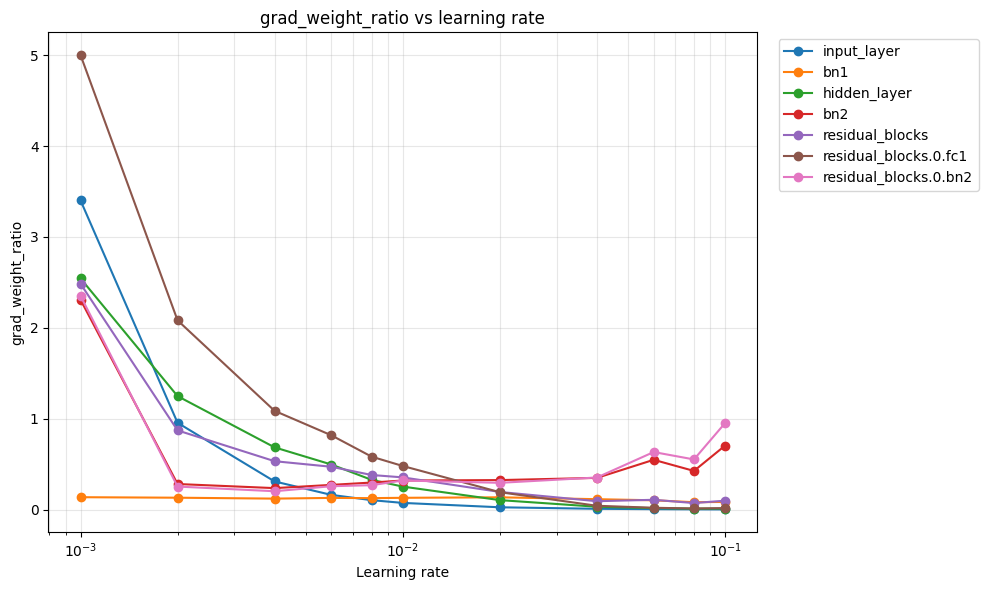

filename = nrd1_grad_weight_ratio_no-outp.png


In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

for layer in layers[:-1]:
    ax.plot(
        metric_df["lr"],
        metric_df[layer],
        marker="o",
        label=layer,
    )

ax.set_xscale("log")

ax.set_xlabel("Learning rate")
ax.set_ylabel(metric)
ax.set_title(f"{metric} vs learning rate")

ax.grid(True, which="both", alpha=0.3)
ax.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

plt.tight_layout()
plt.show()

save_fig(fig, f"nrd{cfg['nrd']}_{metric}_no-outp.png")

In [ ]:
# metric = "grad_norm"
# metric = "weight_norm"

# metric ="grad_weight_ratio"

metric ="adam_update_norm"
# metric ="update_weight_ratio"

print(f"metric = {metric}")

col_list = ["lr"] + [
    f"avg_{metric}_{layer}"
    for layer in layers
]

metric_df = result_df[col_list].rename(
    columns={
        f"avg_{metric}_{layer}": layer
        for layer in layers
    }
)

metric_df

metric = adam_update_norm


,lr,input_layer,bn1,hidden_layer,bn2,residual_blocks,residual_blocks.0.fc1,residual_blocks.0.bn2,output_layer
0,0.100,14.912702,0.450536,0.992901,0.166935,0.657853,0.427863,0.187667,0.086731
1,0.080,13.812673,0.452230,0.802364,0.131495,0.503900,0.349366,0.148856,0.065554
2,0.060,11.980909,0.389813,0.664838,0.120998,0.406987,0.246597,0.136565,0.059194
3,0.040,9.924069,0.341391,0.560966,0.079794,0.424012,0.284822,0.075314,0.028137
4,0.020,6.224917,0.220700,0.474530,0.053512,0.367452,0.258377,0.044767,0.015142
5,0.010,3.585326,0.118444,0.304142,0.025266,0.231065,0.167425,0.021088,0.007154
6,0.008,2.981458,0.096308,0.267494,0.019521,0.189872,0.137828,0.014719,0.005427
7,0.006,2.311275,0.075777,0.228403,0.013298,0.191948,0.136417,0.008974,0.003371
8,0.004,1.648876,0.053792,0.175462,0.009429,0.137935,0.102472,0.006281,0.002571
9,0.002,0.961851,0.030158,0.117812,0.004518,0.092873,0.073799,0.002354,0.001025


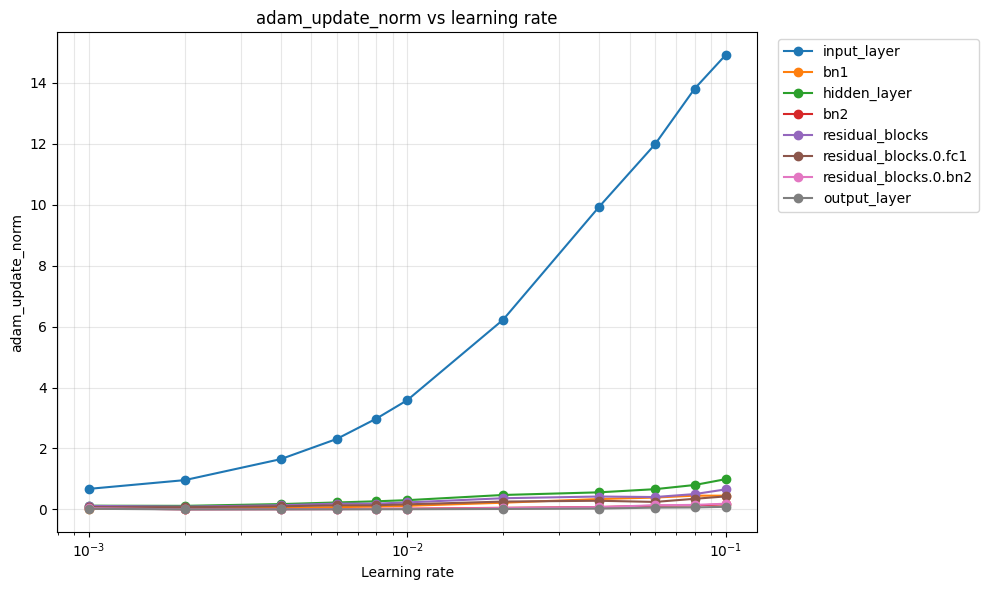

filename = nrd1_adam_update_norm.png


In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

for layer in layers:
    ax.plot(
        metric_df["lr"],
        metric_df[layer],
        marker="o",
        label=layer,
    )

ax.set_xscale("log")

ax.set_xlabel("Learning rate")
ax.set_ylabel(metric)
ax.set_title(f"{metric} vs learning rate")

ax.grid(True, which="both", alpha=0.3)
ax.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

plt.tight_layout()
plt.show()

save_fig(fig, f"nrd{cfg['nrd']}_{metric}.png")

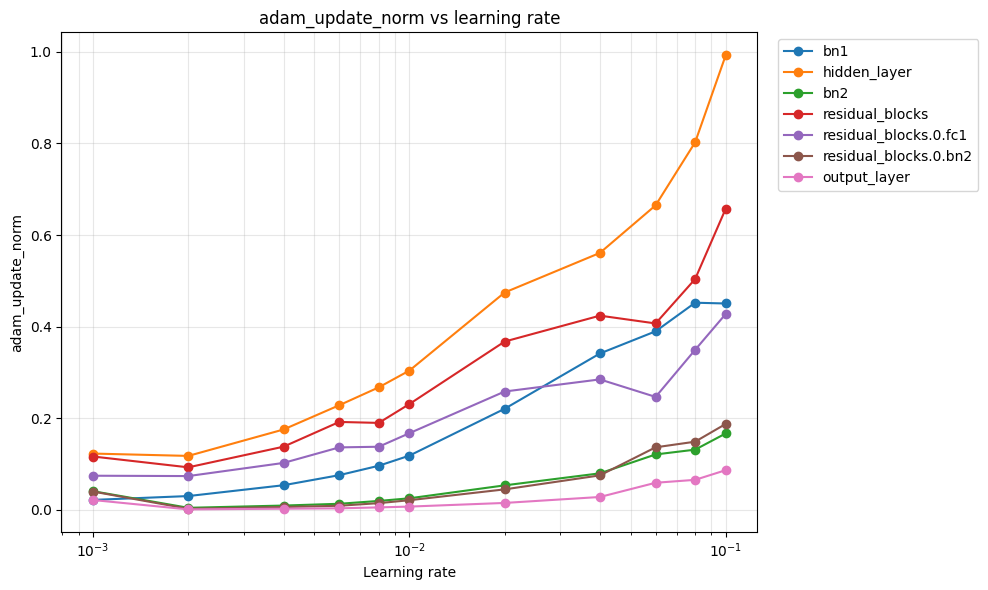

filename = nrd1_adam_update_norm_no_inp.png


In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

for layer in layers[1:]:
    ax.plot(
        metric_df["lr"],
        metric_df[layer],
        marker="o",
        label=layer,
    )

ax.set_xscale("log")

ax.set_xlabel("Learning rate")
ax.set_ylabel(metric)
ax.set_title(f"{metric} vs learning rate")

ax.grid(True, which="both", alpha=0.3)
ax.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

plt.tight_layout()
plt.show()

save_fig(fig, f"nrd{cfg['nrd']}_{metric}_no_inp.png")

In [ ]:
# metric = "grad_norm"
# metric = "weight_norm"

# metric ="grad_weight_ratio"

# metric ="adam_update_norm"
metric ="update_weight_ratio"

print(f"metric = {metric}")

col_list = ["lr"] + [
    f"avg_{metric}_{layer}"
    for layer in layers
]

metric_df = result_df[col_list].rename(
    columns={
        f"avg_{metric}_{layer}": layer
        for layer in layers
    }
)

metric_df

metric = update_weight_ratio


,lr,input_layer,bn1,hidden_layer,bn2,residual_blocks,residual_blocks.0.fc1,residual_blocks.0.bn2,output_layer
0,0.100,0.017056,0.018971,0.009282,0.012801,0.005888,0.005660,0.017888,0.018080
1,0.080,0.019476,0.020395,0.009254,0.010606,0.005519,0.005662,0.013417,0.014958
2,0.060,0.022016,0.018853,0.009997,0.010188,0.005593,0.005158,0.011932,0.014734
3,0.040,0.026290,0.018192,0.012161,0.006927,0.007822,0.008345,0.006279,0.007856
4,0.020,0.030098,0.012983,0.017623,0.004385,0.010335,0.012606,0.003465,0.004675
5,0.010,0.031055,0.007293,0.017808,0.001935,0.008804,0.012599,0.001582,0.002486
6,0.008,0.030892,0.005978,0.017624,0.001475,0.007682,0.011511,0.001097,0.001963
7,0.006,0.030444,0.004738,0.017500,0.000992,0.008239,0.013009,0.000663,0.001268
8,0.004,0.030476,0.003382,0.016084,0.000694,0.006280,0.011413,0.000460,0.001015
9,0.002,0.030783,0.001902,0.013345,0.000329,0.004420,0.009532,0.000171,0.000428


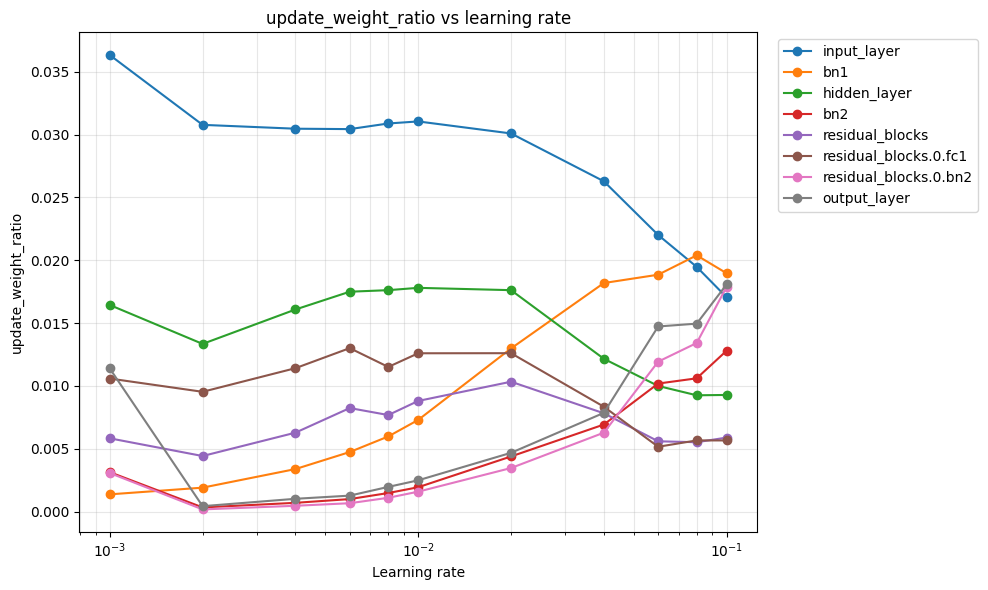

filename = nrd1_update_weight_ratio.png


In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

for layer in layers:
    ax.plot(
        metric_df["lr"],
        metric_df[layer],
        marker="o",
        label=layer,
    )

ax.set_xscale("log")

ax.set_xlabel("Learning rate")
ax.set_ylabel(metric)
ax.set_title(f"{metric} vs learning rate")

ax.grid(True, which="both", alpha=0.3)
ax.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

plt.tight_layout()
plt.show()

save_fig(fig, f"nrd{cfg['nrd']}_{metric}.png")

# end